### Model inspired by:

- [1] Offshore Pipelaying Dynamics. Gullik Anthon Jensen
- [2] A nonlinear PDE formulation for offshore vessel pipeline installation. Gullik A. Jensen et al
- [3] Modeling and Control of Offshore Pipelay Operations Based on a Finite Strain Pipe Model. Gullik A. Jensen

### Implementation aspects:

- The model can be applied to normal dynamic pipelay condition as a rough estimate

In [1]:
import numpy as np
import inspect
import matplotlib.pyplot as plt
import scipy
from datetime import datetime
from scipy.optimize import root
from scipy.integrate import solve_ivp
from scipy import interpolate
import plotly.graph_objects as go

In [2]:
import sys

In [3]:
sys.path.insert(0, "../../../miscellaneous/Ocean_Intella_1/PythonVehicleSimulator-master/src/python_vehicle_simulator")
sys.path.insert(0, "../../../miscellaneous/Ocean_Intella_1/PythonVehicleSimulator-master/src")

In [4]:
from python_vehicle_simulator.vehicles import *
from python_vehicle_simulator.lib import *
from python_vehicle_simulator.lib.gnc import ssa

### Modelling data:

In [5]:
mp = 179.7       #  (submerged pipe weight) [kg/m]
N = 20       # number of modelling nodes

In [6]:
mi = [mp for i in range(N)]

In [7]:
# Vessel:

# L - the hull length
# Xg - x-center of gravity

L = 168 # [m]
B = 46
H = 13.5
Xg = L/2 # [m]
mn = 39_989_000  # mass of the vessel, [kg]

In [8]:
Fx_0 = 1515*1000
Fy_0 = 0.7*Fx_0
LTD = 209

In [9]:
lx, ly, lz = L/2, B/2, H/2

In [10]:
vessel_mass = mn/L # mass over length of the vessel

In [11]:
diag_Jrho0 = 1e2*np.array([1, 1, 2]) # [m^4] 
Jrho0 = np.diag(diag_Jrho0)

In [12]:
qw = 1025 # Water density [kg/m3]
d0 = 0.508 # Outer diameter of pipe, [m]
dI= (508-33*2)/1000 # Inner diameter of pipe, [m]

In [13]:
rho_steel=7850 #kg/m^3

In [14]:
# Ar=np.pi*((d0/2)**2-(dI/2)**2)
Ar=np.pi*(d0/2)**2

Iy_ = 1/4*np.pi*rho_steel*((d0/2)**4-(dI/2)**4)
Iz_ = 1/2*np.pi*rho_steel*((d0/2)**4-(dI/2)**4)
J_ = 1/32*np.pi*(d0**4-dI**4)

In [15]:
E = 207e9
G = 79.3e9

In [16]:
h = 34 # water depth

In [17]:
# Fossen book p.181
def vessel_inertia_moment(mn, Xg, L):
    r = 0.25*L
    Ir = mn*r**2
    Iz=mn*Xg**2 + Ir
    return Iz

In [18]:
vessel_inertia = vessel_inertia_moment(mn, Xg, L)

In [19]:
# Underwater current: 
dv1_curr = np.zeros(N)
dv2_curr = np.zeros(N)
dv3_curr = np.zeros(N)

In [20]:
# Constants: 

In [21]:
diag_DT = 1.5*np.array([1, 1, 1])
DT=np.diag(diag_DT)

In [22]:
diag_CT = 1e9*np.array([1, 1, 1 ])  
CT=np.diag(diag_CT)

In [23]:
# diag_CR = 1e11*np.array([1, 1, 1]) 
diag_CR = 1e7*np.array([1, 1, 1])                ### !!! ### !!! ### !!! ###
CR=np.diag(diag_CR)

In [24]:
diag_DR = 1.5*np.array([1, 1, 1])
DR=np.diag(diag_DR)

In [25]:
# for testing:

In [26]:
φ = np.random.rand(N)
θ = np.random.rand(N)
ψ = np.random.rand(N)

In [27]:
φ

array([0.31192339, 0.07810356, 0.52794925, 0.25000388, 0.84283552,
       0.30652519, 0.3340224 , 0.072204  , 0.43099073, 0.68609189,
       0.63448217, 0.75785318, 0.97098154, 0.54269045, 0.92266359,
       0.83957208, 0.19807877, 0.96149651, 0.25525181, 0.84778794])

In [28]:
dφ = np.random.rand(N)
dθ = np.random.rand(N)
dψ = np.random.rand(N)

In [29]:
ddφ = np.random.rand(N)
ddθ = np.random.rand(N)
ddψ = np.random.rand(N)

In [30]:
x = np.random.rand(N)
y = np.random.rand(N)
z = np.random.rand(N)

In [31]:
dx = np.random.rand(N)
dy = np.random.rand(N)
dz = np.random.rand(N)

In [32]:
# integration parameters
tspan = (0., 5)

coefs = [1, 1, 1, 1, 1, 1]
vessel_motion_calibration_coefficient = 5e2 #  to control the force from the vessel   ### !!! ### !!! ### !!! ###

### Main functions:

In [33]:
def Π0(φθψ):
    φ0,θ0,ψ0=φθψ
    return np.array([[np.cos(θ0),0,np.cos(φ0)*np.sin(θ0)],
                  [0,1,-np.sin(φ0)],
                  [-np.sin(θ0),0,np.cos(φ0)*np.cos(θ0)]])

In [34]:
def Π(φ,θ,ψ):
    φθψ=np.stack((φ,θ,ψ), axis=1)
    return np.apply_along_axis(Π0, 1, φθψ)

In [35]:
Π(φ,θ,ψ)

array([[[ 0.90501313,  0.        ,  0.40485678],
        [ 0.        ,  1.        , -0.30688978],
        [-0.42538364,  0.        ,  0.86134177]],

       [[ 0.65700416,  0.        ,  0.7515887 ],
        [ 0.        ,  1.        , -0.07802418],
        [-0.75388695,  0.        ,  0.65500126]],

       [[ 0.76071394,  0.        ,  0.56070884],
        [ 0.        ,  1.        , -0.50376288],
        [-0.64908728,  0.        ,  0.65713664]],

       [[ 0.81502468,  0.        ,  0.56141273],
        [ 0.        ,  1.        , -0.24740772],
        [-0.57942625,  0.        ,  0.78968675]],

       [[ 0.99879329,  0.        ,  0.03267641],
        [ 0.        ,  1.        , -0.74653273],
        [-0.04911171,  0.        ,  0.66454581]],

       [[ 0.65118853,  0.        ,  0.72354129],
        [ 0.        ,  1.        , -0.30174762],
        [-0.758916  ,  0.        ,  0.62083522]],

       [[ 0.66301019,  0.        ,  0.70723562],
        [ 0.        ,  1.        , -0.32784576],
        

In [36]:
def dΠ0(φ0, θ0, ψ0, dφ0, dθ0, dψ0):
    """Time derivative of Π0 via chain rule: dΠ/dt = ∂Π/∂φ·dφ + ∂Π/∂θ·dθ + ∂Π/∂ψ·dψ"""
    
    # ∂Π/∂φ
    dPi_dphi = np.array([
        [0,              0,  -np.sin(φ0)*np.sin(θ0)],
        [0,              0,  -np.cos(φ0)            ],
        [0,              0,  -np.sin(φ0)*np.cos(θ0)]
    ])
    
    # ∂Π/∂θ
    dPi_dtheta = np.array([
        [-np.sin(θ0),   0,   np.cos(φ0)*np.cos(θ0)],
        [0,              0,   0                     ],
        [-np.cos(θ0),   0,  -np.cos(φ0)*np.sin(θ0)]
    ])
    
    # ∂Π/∂ψ — Π0 as defined doesn't depend on ψ, so this is zero
    dPi_dpsi = np.zeros((3, 3))
    
    return dPi_dphi * dφ0 + dPi_dtheta * dθ0 + dPi_dpsi * dψ0


def dΠ(φ, θ, ψ, dφ, dθ, dψ):
    return np.array([dΠ0(φ[i], θ[i], ψ[i], dφ[i], dθ[i], dψ[i]) for i in range(len(φ))])

In [37]:
dΠ(φ, θ, ψ, dφ, dθ, dψ)

array([[[-0.30502194,  0.        ,  0.56288555],
        [ 0.        ,  0.        , -0.39908772],
        [-0.64894093,  0.        , -0.40676533]],

       [[-0.23601684,  0.        ,  0.14665482],
        [ 0.        ,  0.        , -0.98988038],
        [-0.20568607,  0.        , -0.28619596]],

       [[-0.08913513,  0.        , -0.19069439],
        [ 0.        ,  0.        , -0.74218252],
        [-0.10446413,  0.        , -0.40624728]],

       [[-0.49628791,  0.        ,  0.66520514],
        [ 0.        ,  0.        , -0.07552522],
        [-0.69808175,  0.        , -0.49657685]],

       [[-0.0415106 ,  0.        ,  0.55813819],
        [ 0.        ,  0.        , -0.06450731],
        [-0.84420819,  0.        , -0.09991   ]],

       [[-0.75244473,  0.        ,  0.56113548],
        [ 0.        ,  0.        , -0.22650506],
        [-0.64563584,  0.        , -0.76405467]],

       [[-0.40384935,  0.        ,  0.30196495],
        [ 0.        ,  0.        , -0.13833666],
        

In [38]:
def w_e(φ,θ,ψ,dφ,dθ,dψ): 
    return np.einsum('ijk,ik->ij', Π(φ,θ,ψ), np.stack((dφ,dθ,dψ), axis=1))

In [39]:
w_e(φ,θ,ψ,dφ,dθ,dψ)

array([[ 0.42652618,  0.68139852, -0.07830648],
       [ 1.17722392,  0.25857764, -0.29111299],
       [ 0.73767452,  0.06176868, -0.45911452],
       [ 0.10360304,  0.83885639,  0.01120161],
       [ 0.12943529,  0.10044913,  0.65822317],
       [ 0.49501992,  0.84954873,  0.11170164],
       [ 0.4544676 ,  0.37379695,  0.20689937],
       [ 1.12052438,  0.82964229,  0.74650985],
       [ 0.98351721,  0.61669859, -0.08658142],
       [ 0.82162632,  0.19475345,  0.06776523],
       [ 0.72728541, -0.0635635 ,  0.13172723],
       [ 0.39245658,  0.76685874,  0.03603654],
       [ 0.57736596,  0.29578555, -0.20240595],
       [ 0.46648103,  0.07579738,  0.15494437],
       [ 0.12509546, -0.123859  ,  0.46757654],
       [ 0.28627586, -0.10113081,  0.17653456],
       [ 0.94635506,  0.20021861, -0.27534832],
       [ 0.49775798, -0.62041049,  0.37080343],
       [ 0.34178681,  0.88823691,  0.07997093],
       [ 0.60442766,  0.1612698 ,  0.24426014]])

In [40]:
def dw_e(φ, θ, ψ, dφ, dθ, dψ, ddφ, ddθ, ddψ):
    """ẇ = Π·[ddφ,ddθ,ddψ] + dΠ·[dφ,dθ,dψ]"""
    return (
        np.einsum('ijk,ik->ij', Π(φ, θ, ψ),   np.stack((ddφ, ddθ, ddψ), axis=1)) +
        np.einsum('ijk,ik->ij', dΠ(φ, θ, ψ, dφ, dθ, dψ), np.stack((dφ, dθ, dψ), axis=1))
    )

In [41]:
dw_e(φ,θ,ψ,dφ,dθ,dψ,ddφ,ddθ,ddψ)

array([[ 0.82220573,  0.56398532,  0.25608591],
       [ 0.72201341,  0.04740128, -0.14076692],
       [ 1.12789399, -0.28971911, -0.12121039],
       [ 0.89333732, -0.09042257, -0.07924352],
       [ 1.34155206, -0.27631358,  0.19433211],
       [ 0.83753292,  0.64828698, -0.83058192],
       [ 0.93053167,  0.4367434 , -0.63085043],
       [ 1.17219308, -0.25765009, -0.3015861 ],
       [ 0.08557619,  0.10769662,  0.02094409],
       [ 0.50741976, -0.16579224, -0.47250148],
       [ 0.30171063, -0.10299729, -0.1381744 ],
       [ 0.71227769,  0.35324212, -0.35641807],
       [-0.03729515,  0.33401134, -0.92016782],
       [ 0.40295015, -0.09082192, -0.34700017],
       [ 0.31527246, -0.37960178,  0.16338784],
       [ 0.54554987,  0.62104626, -0.25546031],
       [ 0.87263449,  0.07151098, -0.09316989],
       [ 0.92085117,  0.1962359 , -0.43330289],
       [ 0.8558021 ,  0.80162357, -0.83245871],
       [ 1.02723847,  0.32664337, -0.64335943]])

In [42]:
def phi(x,y,z): return np.stack((x,y,z), axis=1) 
def theta(φ,θ,ψ): return np.stack((φ,θ,ψ), axis=1) 

In [43]:
phi(x,y,z)

array([[0.55255665, 0.42856081, 0.31895002],
       [0.07441561, 0.74406846, 0.91154224],
       [0.17826708, 0.10797544, 0.77588678],
       [0.05253757, 0.77989942, 0.25696667],
       [0.05594984, 0.9362635 , 0.82930176],
       [0.80812635, 0.47168124, 0.21744772],
       [0.93012222, 0.45034064, 0.24826668],
       [0.40897023, 0.81977661, 0.28890445],
       [0.72169436, 0.72665021, 0.50341551],
       [0.39638472, 0.72594157, 0.75068281],
       [0.09118943, 0.46979894, 0.25481977],
       [0.57429376, 0.38789188, 0.88165052],
       [0.7723835 , 0.80928137, 0.01436583],
       [0.23753459, 0.92894047, 0.44306007],
       [0.63596051, 0.09814342, 0.36755588],
       [0.94427187, 0.6625254 , 0.2365482 ],
       [0.13252691, 0.47221437, 0.09902844],
       [0.66051798, 0.95550576, 0.77866198],
       [0.59103058, 0.64845599, 0.38530816],
       [0.45498792, 0.9192648 , 0.94788076]])

In [44]:
theta(φ,θ,ψ)

array([[0.31192339, 0.43938575, 0.97187084],
       [0.07810356, 0.85395834, 0.5644704 ],
       [0.52794925, 0.706384  , 0.88440756],
       [0.25000388, 0.61802455, 0.25492406],
       [0.84283552, 0.04913147, 0.78261915],
       [0.30652519, 0.86164685, 0.89231218],
       [0.3340224 , 0.84596365, 0.28403109],
       [0.072204  , 0.17422342, 0.74569102],
       [0.43099073, 0.20018357, 0.49971619],
       [0.68609189, 0.3628779 , 0.4548374 ],
       [0.63448217, 0.51076173, 0.19944811],
       [0.75785318, 0.14950665, 0.32134527],
       [0.97098154, 0.97773994, 0.8389368 ],
       [0.54269045, 0.86452249, 0.3269095 ],
       [0.92266359, 0.01900281, 0.31881126],
       [0.83957208, 0.92431538, 0.4255265 ],
       [0.19807877, 0.30330344, 0.72089284],
       [0.96149651, 0.197137  , 0.55830824],
       [0.25525181, 0.7792095 , 0.53681438],
       [0.84778794, 0.17544099, 0.43196296]])

In [45]:
def ω(φ,θ,ψ): 
    return np.einsum('ijk,ik->ij', Π(φ,θ,ψ), theta(φ,θ,ψ))

In [46]:
ω(x,y,z)

array([[ 0.61540521,  0.26115507,  0.01731208],
       [ 0.67041585,  0.67629808,  0.61838233],
       [ 0.25951785, -0.02960821,  0.73993288],
       [ 0.21780505,  0.76640522,  0.14550234],
       [ 0.69999916,  0.8898884 ,  0.4457828 ],
       [ 0.78814328,  0.31446783, -0.23337916],
       [ 0.9019815 ,  0.25130698, -0.27125389],
       [ 0.47284576,  0.70488951, -0.11806892],
       [ 0.79046774,  0.39406495, -0.19702214],
       [ 0.75613997,  0.43611352,  0.25475002],
       [ 0.1961893 ,  0.44659426,  0.18498629],
       [ 0.81160502, -0.0910577 ,  0.46800166],
       [ 0.54040656,  0.79925626, -0.55194465],
       [ 0.48712807,  0.82468527,  0.06754262],
       [ 0.66187451, -0.12016659,  0.23196113],
       [ 0.82981627,  0.47090475, -0.47147737],
       [ 0.16267263,  0.45912882,  0.02713663],
       [ 0.88337057,  0.47777641, -0.18447112],
       [ 0.66429573,  0.4337557 , -0.10195339],
       [ 0.952942  ,  0.50271722,  0.15453671]])

In [47]:
def Ret(φ,θ,ψ):
    
    def Ret0(arr):
        φ,θ,ψ=arr
        Cφ=np.matrix([[1,0,0],
                      [0,np.cos(φ),-np.sin(φ)],
                      [0,np.sin(φ),np.cos(φ)]])

        Cθ=np.matrix([[np.cos(θ),0,np.sin(θ)],
                      [0,1,0],
                      [-np.sin(θ),0,np.cos(θ)]])

        Cψ=np.matrix([[np.cos(ψ),-np.sin(ψ),0],
                      [np.sin(ψ),np.cos(ψ),0],
                      [0,0,1]])

        return np.array(Cθ @ Cφ @ Cψ)
    
    arr=np.stack((φ,θ,ψ), axis=1)
    return np.apply_along_axis(Ret0, 1, arr)

In [48]:
Ret(φ,θ,ψ)

array([[[ 0.61802928, -0.67389228,  0.40485678],
        [ 0.78608608,  0.53655134, -0.30688978],
        [-0.01041579,  0.50791915,  0.86134177]],

       [[ 0.58655204, -0.30177993,  0.7515887 ],
        [ 0.53333757,  0.84229642, -0.07802418],
        [-0.60951434,  0.44661574,  0.65500126]],

       [[ 0.73503755, -0.38121567,  0.56070884],
        [ 0.66821604,  0.54745803, -0.50376288],
        [-0.11492226,  0.74495927,  0.65713664]],

       [[ 0.82483506, -0.06680468,  0.56141273],
        [ 0.24433226,  0.93759862, -0.24740772],
        [-0.50985181,  0.34124181,  0.78968675]],

       [[ 0.73406633, -0.67829114,  0.03267641],
        [ 0.46916331,  0.4717782 , -0.74653273],
        [ 0.49095052,  0.56333511,  0.66454581]],

       [[ 0.58697786, -0.36324233,  0.72354129],
        [ 0.74223625,  0.59835919, -0.30174762],
        [-0.32333007,  0.71415775,  0.62083522]],

       [[ 0.70522165,  0.04980161,  0.70723562],
        [ 0.26473968,  0.9068793 , -0.32784576],
        

In [49]:
def d_s(func, a, b, c, φ, θ, ψ): 
    
    sig = inspect.signature(func)
    num_args = len(sig.parameters)
    
    if num_args==3:
        fu = func(a, b, c)
    else:
        fu = func(a, b, c, φ, θ, ψ)

    def S(arr):
        a1, a2, a3 = arr[0],arr[1],arr[2]
        return np.array([[0, -a3, a2 ],
                         [a3, 0, -a1],
                        [-a2, a1, 0]])
    
    S0 = np.apply_along_axis(S, 1, ω(φ,θ,ψ))

    
    return np.einsum('ijk,ik->ij',S0, fu).T

In [50]:
d_s(phi,x,y,z,φ, θ, ψ).T

array([[-0.25687637,  0.17370048,  0.21162415],
       [ 0.50698078, -0.41036471,  0.29358174],
       [ 0.17664064, -0.65385368,  0.05040803],
       [ 0.09857841, -0.08617   ,  0.24137318],
       [-0.89195836, -0.69254661,  0.84204698],
       [-0.02276101,  0.07589956, -0.0800497 ],
       [ 0.21939626, -0.17195599, -0.51004252],
       [-0.55542452,  0.23665648,  0.1147322 ],
       [-0.26536969,  0.00118472,  0.3787228 ],
       [-0.00594293, -0.54139643,  0.52669097],
       [ 0.1799066 , -0.17655828,  0.26113089],
       [-0.10866414, -0.62364262,  0.34516062],
       [ 0.44151052, -0.43090712,  0.53666661],
       [ 0.52299454, -0.30532505,  0.35976951],
       [-0.10359871, -0.2291845 ,  0.24044681],
       [ 0.47430805, -0.64446027, -0.08837291],
       [-0.27460115,  0.04192842,  0.16755631],
       [-0.32244385, -0.70034055,  1.132917  ],
       [ 0.12468618, -0.09820967, -0.02597582],
       [-0.26338538, -0.7778364 ,  0.88078041]])

In [51]:
d_s(theta, φ, θ, ψ, φ, θ, ψ).T

array([[-0.17235598, -0.43702771,  0.25289946],
       [ 0.19172274, -0.24416346,  0.34285447],
       [ 0.0622332 , -0.66785633,  0.49627239],
       [ 0.10658291, -0.07431422,  0.07563772],
       [-0.44231354, -0.27537769,  0.49363381],
       [ 0.25170828, -0.6557069 ,  0.54670649],
       [ 0.27486358, -0.14405496,  0.10581471],
       [-0.0356338 , -0.09717919,  0.02615533],
       [-0.07620511, -0.10135387,  0.1063265 ],
       [ 0.00297722, -0.28992098,  0.22681351],
       [ 0.16513614, -0.23393855,  0.07375815],
       [-0.04056436, -0.16262786,  0.17132904],
       [ 0.76776863, -1.30953733,  0.63759009],
       [ 0.4272967 , -0.31022751,  0.11106689],
       [-0.07829443, -0.13389535,  0.23457079],
       [ 0.71975431, -0.73065499,  0.16701666],
       [-0.07026283, -0.16656528,  0.08938554],
       [-0.17019605, -0.44116059,  0.44887746],
       [ 0.19733911, -0.24488379,  0.26162601],
       [-0.08753758, -0.26900841,  0.28106207]])

In [52]:
def ne(x, y, z, φ, θ, ψ):
    RET = Ret(φ,θ,ψ)
    A = np.einsum('ijk,ikp->ijp',np.einsum('ijk,kp->ijp',RET, CT), np.transpose(RET,(0,2,1))) 
    B = d_s(phi, x, y, z, φ, θ, ψ).T
#     t1=np.einsum('ijk,kp->ijp',RET, np.array([0,0,1]).reshape(3,1)).squeeze()
    return np.einsum('ijk,ik->ij', A, B 
#                      - t1
                    )

In [53]:
ne(x, y, z, φ, θ, ψ)

array([[-2.56876367e+08,  1.73700477e+08,  2.11624148e+08],
       [ 5.06980781e+08, -4.10364708e+08,  2.93581736e+08],
       [ 1.76640638e+08, -6.53853676e+08,  5.04080310e+07],
       [ 9.85784124e+07, -8.61699990e+07,  2.41373175e+08],
       [-8.91958363e+08, -6.92546614e+08,  8.42046978e+08],
       [-2.27610127e+07,  7.58995628e+07, -8.00497033e+07],
       [ 2.19396255e+08, -1.71955990e+08, -5.10042516e+08],
       [-5.55424519e+08,  2.36656482e+08,  1.14732199e+08],
       [-2.65369690e+08,  1.18472348e+06,  3.78722800e+08],
       [-5.94292767e+06, -5.41396428e+08,  5.26690974e+08],
       [ 1.79906598e+08, -1.76558281e+08,  2.61130893e+08],
       [-1.08664136e+08, -6.23642617e+08,  3.45160622e+08],
       [ 4.41510523e+08, -4.30907117e+08,  5.36666614e+08],
       [ 5.22994544e+08, -3.05325053e+08,  3.59769514e+08],
       [-1.03598712e+08, -2.29184498e+08,  2.40446811e+08],
       [ 4.74308051e+08, -6.44460269e+08, -8.83729061e+07],
       [-2.74601145e+08,  4.19284197e+07

In [54]:
d_s(ne, x, y, z, φ, θ, ψ).T

array([[-9.24929017e+07, -3.23958175e+08,  1.53632982e+08],
       [ 3.65337415e+08,  1.79768537e+07, -6.05766503e+08],
       [ 1.69087574e+08, -3.11460311e+06, -6.32919614e+08],
       [ 1.38815509e+08, -7.81619069e+07, -8.45969064e+07],
       [-1.19078277e+08, -1.15735891e+09, -1.07801332e+09],
       [-7.18114195e+07,  6.03461460e+07,  7.76360994e+07],
       [-3.96388870e+08,  1.99581549e+08, -2.37794836e+08],
       [-1.56569205e+08, -4.22840923e+08,  1.14228354e+08],
       [-3.67635220e+06, -2.89491857e+08, -1.67041605e+06],
       [ 8.56293407e+07, -4.04128481e+08, -4.14445734e+08],
       [ 7.24830610e+07, -1.95631776e+08, -1.82209736e+08],
       [ 4.88988461e+07, -2.83475153e+08, -4.96793739e+08],
       [-7.98202585e+07, -7.40622665e+08, -5.29002710e+08],
       [ 1.79701249e+08, -3.24245925e+08, -5.36407810e+08],
       [-1.64587077e+07, -2.40810139e+08, -2.36622193e+08],
       [-3.75266783e+08, -1.71932580e+08, -7.60282115e+08],
       [ 1.24893006e+06, -2.36028344e+08

In [55]:
def me(a, b, c, φ, θ, ψ):
    RET = Ret(φ,θ,ψ)
    A = np.einsum('ijk,ikp->ijp',np.einsum('ijk,kp->ijp', RET, CR), np.transpose(RET,(0,2,1))) 
    return np.einsum('ijk,ik->ij', A, ω(φ,θ,ψ))

In [56]:
me(φ, θ, ψ, φ, θ, ψ)

array([[ 6757632.58382414,  1411285.21517999,  7044258.41905958],
       [ 4755639.37384002,  8099160.02284629,  3108475.62914511],
       [ 8975134.92171217,  2608523.08657147,  2384914.67354802],
       [ 3468769.46620536,  5549543.65375259,   564513.36771838],
       [ 8673916.50317099, -5351193.38562322,  4786931.85686911],
       [ 8452303.9088956 ,  5923937.77954876,  3213519.6063    ],
       [ 4223371.63494468,  7528452.6013794 ,  -721450.82905993],
       [ 2000347.30635544,  1204283.13395313,  7199727.14839801],
       [ 5126650.76843431,   -85834.30906815,  3592494.0732685 ],
       [ 7663328.17143888,   747301.20144685,   854635.50515772],
       [ 6320280.28029588,  3925367.63853995, -1700311.8993026 ],
       [ 7841636.91132579,  -713744.40720736,  1179112.68992969],
       [ 9353820.98731261,  2852478.02010314, -5404952.0554726 ],
       [ 5651821.89328595,  6956927.79696623, -2311890.33727738],
       [ 9261541.76534914, -2351574.89014647,  1748990.92422461],
       [ 7

In [57]:
d_s(me, φ, θ, ψ, φ, θ, ψ).T

array([[ 0.00000000e+00,  6.96225262e-10, -1.16415322e-10],
       [ 0.00000000e+00, -1.40030287e-10,  4.65661287e-10],
       [ 1.16415322e-10,  6.40678738e-10, -1.39698386e-09],
       [ 1.16415322e-10, -1.06892305e-10,  2.32830644e-10],
       [ 4.65661287e-10, -5.75481113e-10, -9.31322575e-10],
       [-9.31322575e-10,  5.76998618e-10,  1.86264515e-09],
       [-5.82076609e-10,  2.08446636e-10, -9.31322575e-10],
       [ 2.32830644e-10, -7.58095116e-11, -5.82076609e-11],
       [-6.18456397e-11,  2.44840111e-10,  9.45874490e-11],
       [-1.45519152e-11, -3.26530858e-10,  4.65661287e-10],
       [ 2.32830644e-10, -5.05224840e-10,  0.00000000e+00],
       [ 7.27595761e-11,  2.32059010e-10, -3.49245965e-10],
       [-6.98491931e-10,  1.66279645e-09, -4.65661287e-10],
       [ 4.65661287e-10, -2.59942034e-10,  4.65661287e-10],
       [ 1.16415322e-10,  1.05662152e-09,  4.65661287e-10],
       [-1.39698386e-09,  2.14700534e-09,  9.31322575e-10],
       [ 0.00000000e+00,  1.31404241e-10

In [58]:
def fD(dx,dy,dz): 
    
    vr1 = dx - dv1_curr
    vr2 = dy - dv2_curr  
    vr3 = dz - dv3_curr

    A = np.vstack([
        np.abs(vr1) * vr1,
        np.sqrt(vr2**2 + vr3**2) * vr2,
        np.sqrt(vr2**2 + vr3**2) * vr3
    ])
    return 0.5 * d0 * qw * np.dot(DT, A)

In [59]:
fD(dx,dy,dz).T

array([[251.53901208, 201.38273565, 131.7952001 ],
       [329.45066919,  38.87078488,  18.74721314],
       [ 24.60407717, 218.89755838, 224.43020367],
       [158.36737189,  34.19834745, 309.43542237],
       [264.13117771, 183.88284655, 110.63172175],
       [276.85522908,  74.53114766,  96.64109589],
       [135.03058706, 110.33560841, 177.75628414],
       [ 92.74102892,  38.21769166,  94.22402333],
       [318.65414244, 244.67285265,  13.32723457],
       [218.6573236 ,  53.63530366,   3.18233065],
       [  2.35178973, 349.65805084, 169.99699212],
       [257.63244873, 254.8105007 , 109.73824532],
       [ 42.0887959 ,  24.81044992, 363.68265845],
       [115.57852832,  50.22914063, 137.61664048],
       [  6.25487098, 208.65450493,  28.86314469],
       [365.84097303,  87.86521169, 394.02975347],
       [307.68502499, 127.42595281, 345.40095208],
       [381.05432968, 392.77023782, 287.18820024],
       [210.67110057, 179.30985   ,  17.31819916],
       [207.33243827, 195.67657

In [60]:
fg_e = np.array([[0,0,(mp-qw*Ar)*9.81] for x in range(N)])          

In [61]:
fg_e

array([[   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.

In [62]:
def sigma(x,y,z):
    e3 = np.array([[0,0,1] for x in range(N)])
    
    k = phi(x,y,z)*e3+d0/2
    
    fg_e2 = np.linalg.norm(fg_e, ord=2)
    k0=np.zeros(k.shape)
    
    for i in range(k.shape[0]):
        for j in range(k.shape[1]):
            if k[i][j]<0:
                k0[i][j]=0
            elif 0<=k[i][j]<=d0/20:
                k0[i][j]=(fg_e2*10*k[i][j]**2)/((d0/8-d0/40)*d0)
            else:
                k0[i][j]=(fg_e2*(k[i][j]-d0/40))/(d0/8-d0/40)
                
    return k0         

In [63]:
sigma(x,y,z)

array([[ 5845.36330569,  5845.36330569, 13571.75681642],
       [ 5845.36330569,  5845.36330569, 27926.98609163],
       [ 5845.36330569,  5845.36330569, 24640.80511763],
       [ 5845.36330569,  5845.36330569, 12070.24338234],
       [ 5845.36330569,  5845.36330569, 25934.75433211],
       [ 5845.36330569,  5845.36330569, 11112.91798879],
       [ 5845.36330569,  5845.36330569, 11859.4906741 ],
       [ 5845.36330569,  5845.36330569, 12843.91900066],
       [ 5845.36330569,  5845.36330569, 18040.33441342],
       [ 5845.36330569,  5845.36330569, 24030.25249825],
       [ 5845.36330569,  5845.36330569, 12018.2356932 ],
       [ 5845.36330569,  5845.36330569, 27202.87502866],
       [ 5845.36330569,  5845.36330569,  6193.36780426],
       [ 5845.36330569,  5845.36330569, 16578.2563394 ],
       [ 5845.36330569,  5845.36330569, 14749.20770808],
       [ 5845.36330569,  5845.36330569, 11575.61685383],
       [ 5845.36330569,  5845.36330569,  8244.27414634],
       [ 5845.36330569,  5845.3

In [64]:
def ne_hat(x,y,z,dx,dy,dz):
    return fg_e.T - fD(dx,dy,dz) # - sigma(x,y,z).T

In [65]:
ne_hat(x,y,z,dx,dy,dz).T

array([[-251.53901208, -201.38273565, -406.96635178],
       [-329.45066919,  -38.87078488, -293.91836481],
       [ -24.60407717, -218.89755838, -499.60135535],
       [-158.36737189,  -34.19834745, -584.60657404],
       [-264.13117771, -183.88284655, -385.80287343],
       [-276.85522908,  -74.53114766, -371.81224756],
       [-135.03058706, -110.33560841, -452.92743582],
       [ -92.74102892,  -38.21769166, -369.39517501],
       [-318.65414244, -244.67285265, -288.49838625],
       [-218.6573236 ,  -53.63530366, -278.35348233],
       [  -2.35178973, -349.65805084, -445.1681438 ],
       [-257.63244873, -254.8105007 , -384.909397  ],
       [ -42.0887959 ,  -24.81044992, -638.85381013],
       [-115.57852832,  -50.22914063, -412.78779216],
       [  -6.25487098, -208.65450493, -304.03429637],
       [-365.84097303,  -87.86521169, -669.20090515],
       [-307.68502499, -127.42595281, -620.57210376],
       [-381.05432968, -392.77023782, -562.35935192],
       [-210.67110057, -179.

In [66]:
def Jrho(Ret,Jrho0): 
    return np.einsum('ijk,kl,iml->ijm', RET, Jrho0, RET)

In [67]:
RET = Ret(φ, θ, ψ)

In [68]:
Jrho(RET,Jrho0)

array([[[116.39090112, -12.42464079,  34.87200559],
        [-12.42464079, 109.41813373, -26.43369879],
        [ 34.87200559, -26.43369879, 174.19096515]],

       [[156.48855773,  -5.86420919,  49.22915467],
        [ -5.86420919, 100.60877726,  -5.1105936 ],
        [ 49.22915467,  -5.1105936 , 142.90266501]],

       [[131.43944063, -28.24642989,  36.84623229],
        [-28.24642989, 125.37770347, -33.10410416],
        [ 36.84623229, -33.10410416, 143.1828559 ]],

       [[131.51842563, -13.8897846 ,  44.33401958],
        [-13.8897846 , 106.12105815, -19.53746008],
        [ 44.33401958, -19.53746008, 162.36051622]],

       [[100.10677477,  -2.43940091,   2.1714971 ],
        [ -2.43940091, 155.7311117 , -49.61051987],
        [  2.1714971 , -49.61051987, 144.16211352]],

       [[152.35119988, -21.83268628,  44.91999186],
        [-21.83268628, 109.10516266, -18.73355515],
        [ 44.91999186, -18.73355515, 138.54363746]],

       [[150.01822214, -23.18641981,  44.29886685],


### Static solution

In [69]:
def catenary(x,Ws,Fh):
    return (Fh/Ws)*(np.cosh(x*Ws/Fh)-1)

In [70]:
pipe_weight_per_unit_length = mi #  (submerged) [kg/m]  # 113.07 - not submerged

In [71]:
# Fx_0 = 82945396 
# Fy_0 = 82945396 

In [72]:
Ws = np.array(pipe_weight_per_unit_length)*9.81 # [N/m]

In [73]:
horizontal_length=2*(Fx_0/Ws[0])*(np.sinh(LTD*Ws[0]/(2*Fx_0)))

In [74]:
delta_x=horizontal_length/(N-1)

In [75]:
x0=[i*delta_x for i in range(N)]
z0=[]

for i in range(len(x0)):
    z0.append(catenary(x0[i],Ws[0],Fx_0))

length_p=[]
for i in range(1,len(z0)):
    length_p.append(np.sqrt((x0[i]-x0[i-1])**2+(z0[i]-z0[i-1])**2))

In [76]:
cum_len = 0
length_p1=[0]
for i in range(len(length_p)):
    cum_len+=length_p[i]
    length_p1.append(cum_len)

In [77]:
length_p1

[0,
 11.027354079515861,
 22.056523745356273,
 33.08932488275457,
 44.127573974810836,
 55.17308840154847,
 66.22768673911834,
 77.29318905920005,
 88.3714172286495,
 99.46419520944222,
 110.5733493589617,
 121.70070873068227,
 132.84810537529617,
 144.01737464233418,
 155.21035548232967,
 166.42889074957577,
 177.6748275055255,
 188.95001732288486,
 200.2563165904489,
 211.59558681873108]

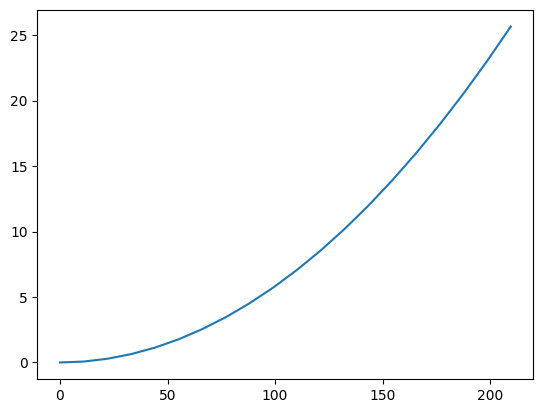

In [78]:
plt.plot(x0, z0)
plt.show()

In [79]:
q0=np.zeros(12*N)

In [80]:
for j in range(1,12):
    if j==1:
        q0[(j-1)*N:j*N]=x0
    elif j==5:
        q0[(j-1)*N:j*N]=z0

In [81]:
def static_func(Q): 
    t=0

    x,y,z=Q[0:N],Q[2*N:3*N],Q[4*N:5*N]
    dx,dy,dz=Q[1*N:2*N],Q[3*N:4*N],Q[5*N:6*N]
    φ,θ,ψ=Q[6*N:7*N],Q[8*N:9*N],Q[10*N:11*N]
    dφ,dθ,dψ=Q[7*N:8*N],Q[9*N:10*N],Q[11*N:12*N]
    
    RET = Ret(φ,θ,ψ)

    η = [x[-1],y[-1],z[-1],φ[-1],θ[-1],ψ[-1]]

    tau_force = np.array([-Fx_0,Fy_0,0,0,0,0])

    Z0 = tau_force[:3]    
    Z1 = d_s(ne, x, y, z, φ, θ, ψ).T
    Z2 = ne_hat(x, y, z, dx, dy, dz).T


    Z = (Z1 + Z2 - Z0)


############################################################
    ddx,ddy, ddz = (Z/mp).T
############################################################
    
    C0 = np.einsum('ijk,kp->ijp', Π(φ,θ,ψ), tau_force[3:].reshape(3,1))
    C1 = d_s(me, φ, θ, ψ, φ, θ, ψ)
    C = (C1.T - C0.squeeze())
 
    A0 = Jrho(RET,Jrho0)
    A_fin = np.einsum('ijk,ikr->ijr',A0, Π(φ,θ,ψ))

    B = np.einsum('ijk,ik->ij', dΠ(φ, θ, ψ, dφ, dθ, dψ), np.stack((dφ,dθ,dψ), axis=1))
    
    D = w_e(φ,θ,ψ,dφ,dθ,dψ)
    
    G = np.cross(d_s(phi,x,y,z,φ, θ, ψ).T, ne(x, y, z, φ, θ, ψ))
    L = np.einsum('ijk,ik->ij',RET, (DR@D.T).T) 
    
    H = np.cross(D,np.einsum('ijk,ik->ij', A0, D))

#############################################
    ddφ,ddθ,ddψ = np.linalg.solve(A_fin, C + G - L - H - np.einsum('ijk,ik->ij',A0, B)).T
#############################################

    ans=np.concatenate([dx, ddx, dy, ddy, dz, ddz, dφ, ddφ, dθ, ddθ, dψ, ddψ], axis=0)

    return ans

In [82]:
root_ = root(static_func, q0, method='df-sane')

In [83]:
root_

 message: too many function evaluations required
 success: False
     fun: [ 6.224e+01  6.224e+01 ...  0.000e+00  0.000e+00]
       x: [ 1.058e+03  1.069e+03 ...  0.000e+00  0.000e+00]
     nit: 330
    nfev: 1000
  method: df-sane

In [84]:
x0_, z0_=root_.x[:N],root_.x[4*N:5*N]

In [85]:
# q0 = root_.x                                            # start from static solution

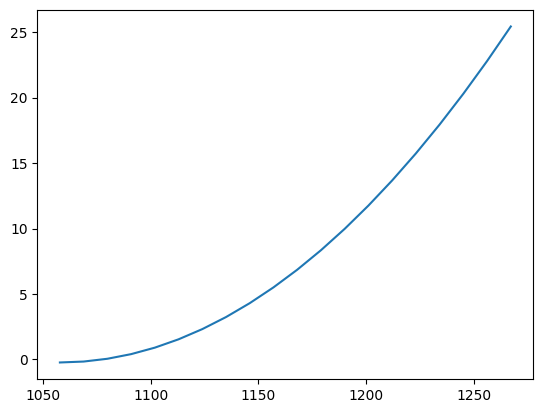

In [86]:
plt.plot(x0_, z0_)
plt.show()

### Finite Element Model of the Space Frame Element

In [87]:
def PlaneTrussElementLength(x1,y1,z1,x2,y2,z2):
    return np.sqrt((x2-x1)*(x2-x1) + (y2-y1)*(y2-y1)+(z2-z1)*(z2-z1))

In [88]:
def SpaceFrameElementStiffness(E,G,A,Iy,Iz,J,x1,y1,z1,x2,y2,z2):
    L = PlaneTrussElementLength(x1,y1,z1,x2,y2,z2)
    w1 = E*A/L
    w2 = 12*E*Iz/(L*L*L)
    w3 = 6*E*Iz/(L*L)
    w4 = 4*E*Iz/L
    w5 = 2*E*Iz/L
    w6 = 12*E*Iy/(L*L*L)
    w7 = 6*E*Iy/(L*L)
    w8 = 4*E*Iy/L
    w9 = 2*E*Iy/L
    w10 = G*J/L

    kprime = np.array([[w1, 0, 0, 0, 0, 0, -w1, 0, 0, 0, 0, 0],
                        [0, w2, 0, 0, 0, w3, 0, -w2, 0, 0, 0, w3],
                        [0, 0, w6, 0, -w7, 0, 0, 0, -w6, 0, -w7, 0],
                        [0, 0, 0, w10, 0, 0, 0, 0, 0, -w10, 0, 0],
                        [0, 0, -w7, 0, w8, 0, 0, 0, w7, 0, w9, 0],
                        [0, w3, 0, 0, 0, w4, 0, -w3, 0, 0, 0, w5],
                        [-w1, 0, 0, 0, 0, 0, w1, 0, 0, 0, 0, 0],
                        [0, -w2, 0, 0, 0, -w3, 0, w2, 0, 0, 0, -w3],
                        [0, 0, -w6, 0, w7, 0, 0, 0, w6, 0, w7, 0],
                        [0, 0, 0, -w10, 0, 0, 0, 0, 0, w10, 0, 0],
                        [0, 0, -w7, 0, w9, 0, 0, 0, w7, 0, w8, 0],
                        [0, w3, 0, 0, 0, w5, 0, -w3, 0, 0, 0, w4]])


    if x1 == x2 and y1 == y2:
        if z2 > z1:
            Lambda = np.array([[0, 0, 1], [0, 1, 0], [-1, 0, 0]])
        else:
            Lambda = np.array([[0, 0, -1], [0, 1, 0], [1, 0, 0]])
    else:
        CXx = (x2-x1)/L
        CYx = (y2-y1)/L
        CZx = (z2-z1)/L
        D = np.sqrt(CXx*CXx + CYx*CYx)
        CXy = -CYx/D
        CYy = CXx/D
        CZy = 0
        CXz = -CXx*CZx/D
        CYz = -CYx*CZx/D
        CZz = D
        Lambda = np.array([[CXx, CYx, CZx], [CXy, CYy, CZy], [CXz, CYz, CZz]])


    R = np.array([np.concatenate((np.concatenate((Lambda,np.zeros((3,3)),np.zeros((3,3)),np.zeros((3,3))),axis=1),
        np.concatenate((np.zeros((3,3)), Lambda, np.zeros((3,3)), np.zeros((3,3))),axis=1) ,
        np.concatenate((np.zeros((3,3)), np.zeros((3,3)), Lambda, np.zeros((3,3))),axis=1),
        np.concatenate((np.zeros((3,3)), np.zeros((3,3)), np.zeros((3,3)), Lambda),axis=1)))])[0]
    return np.dot(np.dot(R.T,kprime),R)

In [89]:
def SpaceFrameAssemble(K,k,i,j):
    K[6*i,6*i] = K[6*i,6*i] + k[0,0]
    K[6*i,6*i+1] = K[6*i,6*i+1] + k[0,1]
    K[6*i,6*i+2] = K[6*i,6*i+2] + k[0,2]
    K[6*i,6*i+3] = K[6*i,6*i+3] + k[0,3]
    K[6*i,6*i+4] = K[6*i,6*i+4] + k[0,4]
    K[6*i,6*i+5] = K[6*i,6*i+5] + k[0,5]
    K[6*i,6*j] = K[6*i,6*j] + k[0,6]
    K[6*i,6*j+1] = K[6*i,6*j+1] + k[0,7]
    K[6*i,6*j+2] = K[6*i,6*j+2] + k[0,8]
    K[6*i,6*j+3] = K[6*i,6*j+3] + k[0,9]
    K[6*i,6*j+4] = K[6*i,6*j+4] + k[0,10]
    K[6*i,6*j+5] = K[6*i,6*j+5] + k[0,11]
    K[6*i+1,6*i] = K[6*i+1,6*i] + k[1,0]
    K[6*i+1,6*i+1] = K[6*i+1,6*i+1] + k[1,1]
    K[6*i+1,6*i+2] = K[6*i+1,6*i+2] + k[1,2]
    K[6*i+1,6*i+3] = K[6*i+1,6*i+3] + k[1,3]
    K[6*i+1,6*i+4] = K[6*i+1,6*i+4] + k[1,4]
    K[6*i+1,6*i+5] = K[6*i+1,6*i+5] + k[1,5]
    K[6*i+1,6*j] = K[6*i+1,6*j] + k[1,6]
    K[6*i+1,6*j+1] = K[6*i+1,6*j+1] + k[1,7]
    K[6*i+1,6*j+2] = K[6*i+1,6*j+2] + k[1,8]
    K[6*i+1,6*j+3] = K[6*i+1,6*j+3] + k[1,9]
    K[6*i+1,6*j+4] = K[6*i+1,6*j+4] + k[1,10]
    K[6*i+1,6*j+5] = K[6*i+1,6*j+5] + k[1,11]
    K[6*i+2,6*i]   = K[6*i+2,6*i] + k[2,0]
    K[6*i+2,6*i+1] = K[6*i+2,6*i+1] + k[2,1]
    K[6*i+2,6*i+2] = K[6*i+2,6*i+2] + k[2,2]
    K[6*i+2,6*i+3] = K[6*i+2,6*i+3] + k[2,3]
    K[6*i+2,6*i+4] = K[6*i+2,6*i+4] + k[2,4]
    K[6*i+2,6*i+5] = K[6*i+2,6*i+5] + k[2,5]
    K[6*i+2,6*j]   = K[6*i+2,6*j] + k[2,6]
    K[6*i+2,6*j+1] = K[6*i+2,6*j+1] + k[2,7]
    K[6*i+2,6*j+2] = K[6*i+2,6*j+2] + k[2,8]
    K[6*i+2,6*j+3] = K[6*i+2,6*j+3] + k[2,9]
    K[6*i+2,6*j+4] = K[6*i+2,6*j+4] + k[2,10]
    K[6*i+2,6*j+5] = K[6*i+2,6*j+5] + k[2,11]
    K[6*i+3,6*i] = K[6*i+3,6*i] + k[3,0]
    K[6*i+3,6*i+1] = K[6*i+3,6*i+1] + k[3,1]
    K[6*i+3,6*i+2] = K[6*i+3,6*i+2] + k[3,2]
    K[6*i+3,6*i+3] = K[6*i+3,6*i+3] + k[3,3]
    K[6*i+3,6*i+4] = K[6*i+3,6*i+4] + k[3,4]
    K[6*i+3,6*i+5] = K[6*i+3,6*i+5] + k[3,5]
    K[6*i+3,6*j] = K[6*i+3,6*j] + k[3,6]
    K[6*i+3,6*j+1] = K[6*i+3,6*j+1] + k[3,7]
    K[6*i+3,6*j+2] = K[6*i+3,6*j+2] + k[3,8]
    K[6*i+3,6*j+3] = K[6*i+3,6*j+3] + k[3,9]
    K[6*i+3,6*j+4] = K[6*i+3,6*j+4] + k[3,10]
    K[6*i+3,6*j+5] = K[6*i+3,6*j+5] + k[3,11]
    K[6*i+4,6*i] = K[6*i+4,6*i] + k[4,0]
    K[6*i+4,6*i+1] = K[6*i+4,6*i+1] + k[4,1]
    K[6*i+4,6*i+2] = K[6*i+4,6*i+2] + k[4,2]
    K[6*i+4,6*i+3] = K[6*i+4,6*i+3] + k[4,3]
    K[6*i+4,6*i+4] = K[6*i+4,6*i+4] + k[4,4]
    K[6*i+4,6*i+5] = K[6*i+4,6*i+5] + k[4,5]
    K[6*i+4,6*j] = K[6*i+4,6*j] + k[4,6]
    K[6*i+4,6*j+1] = K[6*i+4,6*j+1] + k[4,7]
    K[6*i+4,6*j+2] = K[6*i+4,6*j+2] + k[4,8]
    K[6*i+4,6*j+3] = K[6*i+4,6*j+3] + k[4,9]
    K[6*i+4,6*j+4] = K[6*i+4,6*j+4] + k[4,10]
    K[6*i+4,6*j+5] = K[6*i+4,6*j+5] + k[4,11]
    K[6*i+5,6*i] = K[6*i+5,6*i] + k[5,0]
    K[6*i+5,6*i+1] = K[6*i+5,6*i+1] + k[5,1]
    K[6*i+5,6*i+2] = K[6*i+5,6*i+2] + k[5,2]
    K[6*i+5,6*i+3] = K[6*i+5,6*i+3] + k[5,3]
    K[6*i+5,6*i+4] = K[6*i+5,6*i+4] + k[5,4]
    K[6*i+5,6*i+5] = K[6*i+5,6*i+5] + k[5,5]
    K[6*i+5,6*j] = K[6*i+5,6*j] + k[5,6]
    K[6*i+5,6*j+1] = K[6*i+5,6*j+1] + k[5,7]
    K[6*i+5,6*j+2] = K[6*i+5,6*j+2] + k[5,8]
    K[6*i+5,6*j+3] = K[6*i+5,6*j+3] + k[5,9]
    K[6*i+5,6*j+4] = K[6*i+5,6*j+4] + k[5,10]
    K[6*i+5,6*j+5] = K[6*i+5,6*j+5] + k[5,11]
    K[6*j,6*i] = K[6*j,6*i] + k[6,0]
    K[6*j,6*i+1] = K[6*j,6*i+1] + k[6,1]
    K[6*j,6*i+2] = K[6*j,6*i+2] + k[6,2]
    K[6*j,6*i+3] = K[6*j,6*i+3] + k[6,3]
    K[6*j,6*i+4] = K[6*j,6*i+4] + k[6,4]
    K[6*j,6*i+5] = K[6*j,6*i+5] + k[6,5]
    K[6*j,6*j] = K[6*j,6*j] + k[6,6]
    K[6*j,6*j+1] = K[6*j,6*j+1] + k[6,7]
    K[6*j,6*j+2] = K[6*j,6*j+2] + k[6,8]
    K[6*j,6*j+3] = K[6*j,6*j+3] + k[6,9]
    K[6*j,6*j+4] = K[6*j,6*j+4] + k[6,10]
    K[6*j,6*j+5] = K[6*j,6*j+5] + k[6,11]
    K[6*j+1,6*i] = K[6*j+1,6*i] + k[7,0]
    K[6*j+1,6*i+1] = K[6*j+1,6*i+1] + k[7,1]
    K[6*j+1,6*i+2] = K[6*j+1,6*i+2] + k[7,2]
    K[6*j+1,6*i+3] = K[6*j+1,6*i+3] + k[7,3]
    K[6*j+1,6*i+4] = K[6*j+1,6*i+4] + k[7,4]
    K[6*j+1,6*i+5] = K[6*j+1,6*i+5] + k[7,5]
    K[6*j+1,6*j] = K[6*j+1,6*j] + k[7,6]
    K[6*j+1,6*j+1] = K[6*j+1,6*j+1] + k[7,7]
    K[6*j+1,6*j+2] = K[6*j+1,6*j+2] + k[7,8]
    K[6*j+1,6*j+3] = K[6*j+1,6*j+3] + k[7,9]
    K[6*j+1,6*j+4] = K[6*j+1,6*j+4] + k[7,10]
    K[6*j+1,6*j+5] = K[6*j+1,6*j+5] + k[7,11]
    K[6*j+2,6*i] = K[6*j+2,6*i] + k[8,0]
    K[6*j+2,6*i+1] = K[6*j+2,6*i+1] + k[8,1]
    K[6*j+2,6*i+2] = K[6*j+2,6*i+2] + k[8,2]
    K[6*j+2,6*i+3] = K[6*j+2,6*i+3] + k[8,3]
    K[6*j+2,6*i+4] = K[6*j+2,6*i+4] + k[8,4]
    K[6*j+2,6*i+5] = K[6*j+2,6*i+5] + k[8,5]
    K[6*j+2,6*j] = K[6*j+2,6*j] + k[8,6]
    K[6*j+2,6*j+1] = K[6*j+2,6*j+1] + k[8,7]
    K[6*j+2,6*j+2] = K[6*j+2,6*j+2] + k[8,8]
    K[6*j+2,6*j+3] = K[6*j+2,6*j+3] + k[8,9]
    K[6*j+2,6*j+4] = K[6*j+2,6*j+4] + k[8,10]
    K[6*j+2,6*j+5] = K[6*j+2,6*j+5] + k[8,11]
    K[6*j+3,6*i] = K[6*j+3,6*i] + k[9,0]
    K[6*j+3,6*i+1] = K[6*j+3,6*i+1] + k[9,1]
    K[6*j+3,6*i+2] = K[6*j+3,6*i+2] + k[9,2]
    K[6*j+3,6*i+3] = K[6*j+3,6*i+3] + k[9,3]
    K[6*j+3,6*i+4] = K[6*j+3,6*i+4] + k[9,4]
    K[6*j+3,6*i+5] = K[6*j+3,6*i+5] + k[9,5]
    K[6*j+3,6*j] = K[6*j+3,6*j] + k[9,6]
    K[6*j+3,6*j+1] = K[6*j+3,6*j+1] + k[9,7]
    K[6*j+3,6*j+2] = K[6*j+3,6*j+2] + k[9,8]
    K[6*j+3,6*j+3] = K[6*j+3,6*j+3] + k[9,9]
    K[6*j+3,6*j+4] = K[6*j+3,6*j+4] + k[9,10]
    K[6*j+3,6*j+5] = K[6*j+3,6*j+5] + k[9,11]
    K[6*j+4,6*i] = K[6*j+4,6*i] + k[10,0]
    K[6*j+4,6*i+1] = K[6*j+4,6*i+1] + k[10,1]
    K[6*j+4,6*i+2] = K[6*j+4,6*i+2] + k[10,2]
    K[6*j+4,6*i+3] = K[6*j+4,6*i+3] + k[10,3]
    K[6*j+4,6*i+4] = K[6*j+4,6*i+4] + k[10,4]
    K[6*j+4,6*i+5] = K[6*j+4,6*i+5] + k[10,5]
    K[6*j+4,6*j] = K[6*j+4,6*j] + k[10,6]
    K[6*j+4,6*j+1] = K[6*j+4,6*j+1] + k[10,7]
    K[6*j+4,6*j+2] = K[6*j+4,6*j+2] + k[10,8]
    K[6*j+4,6*j+3] = K[6*j+4,6*j+3] + k[10,9]
    K[6*j+4,6*j+4] = K[6*j+4,6*j+4] + k[10,10]
    K[6*j+4,6*j+5] = K[6*j+4,6*j+5] + k[10,11]
    K[6*j+5,6*i] = K[6*j+5,6*i] + k[11,0]
    K[6*j+5,6*i+1] = K[6*j+5,6*i+1] + k[11,1]
    K[6*j+5,6*i+2] = K[6*j+5,6*i+2] + k[11,2]
    K[6*j+5,6*i+3] = K[6*j+5,6*i+3] + k[11,3]
    K[6*j+5,6*i+4] = K[6*j+5,6*i+4] + k[11,4]
    K[6*j+5,6*i+5] = K[6*j+5,6*i+5] + k[11,5]
    K[6*j+5,6*j] = K[6*j+5,6*j] + k[11,6]
    K[6*j+5,6*j+1] = K[6*j+5,6*j+1] + k[11,7]
    K[6*j+5,6*j+2] = K[6*j+5,6*j+2] + k[11,8]
    K[6*j+5,6*j+3] = K[6*j+5,6*j+3] + k[11,9]
    K[6*j+5,6*j+4] = K[6*j+5,6*j+4] + k[11,10]
    K[6*j+5,6*j+5] = K[6*j+5,6*j+5] + k[11,11]

    return K

In [90]:
def FEA(coord, elcon, bc_node, bc_val, vessel_movement, coefs,
          E=210e6, G=84e6, A=2e-2, Iy=10e-5, Iz=20e-5, J=5e-5):

    coord=np.array(coord)
    elcon=np.array(elcon)

    K=np.zeros(shape=(6*(np.max(elcon)+1),6*(np.max(elcon)+1)))

    for el in elcon:
        k=SpaceFrameElementStiffness(E,G,A,Iy,Iz,J,
                                     coord[el[0]][0],coord[el[0]][1],coord[el[0]][2],\
                                     coord[el[1]][0],coord[el[1]][1],coord[el[1]][2])
        K=SpaceFrameAssemble(K,k,el[0],el[1])
        
        
    glob_force=np.dot(K, np.array(vessel_movement))
    
    glob_force[-6:]=np.multiply(glob_force[-6:], coefs)
    glob_force = np.zeros(len(vessel_movement))


    F=np.zeros(len(coord)*6)
    for i in range(len(vessel_movement)):
        if vessel_movement[i]:
            F[i]=glob_force[i]

    # https://github.com/CALFEM/calfem-matlab/blob/master/fem/solveq.m

    bc=np.array([bc_node,
                bc_val]).T
    nd, nd=K.shape
    fdof=np.array([i for i in range(nd)]).T
    d=np.zeros(shape=(len(fdof),))
    Q=np.zeros(shape=(len(fdof),))

    pdof=bc[:,0].astype(int)
    dp=bc[:,1]
    fdof=np.delete(fdof, pdof, 0)
    s=scipy.linalg.lstsq(K[fdof,:][:,fdof], (F[fdof].T-np.dot(K[fdof,:][:,pdof],dp.T)).T, check_finite=True)[0]
    d[pdof]=dp
    d[fdof]=s.reshape(-1,)
    

#     Q=np.dot(K,d).T-F
    return d, np.dot(K,d).T

In [91]:
# 10 The Space Frame Element - verification
d,f=FEA(np.array([0,0,0,
                  3,0,0,
                  0,0,-3,
                  0,-4,0]).reshape(4,3),
        elcon=np.array([[0, 1],
                      [0, 2],
                      [0, 3]]),
        bc_node=list(range(6)),
        bc_val=[ -0.0705e-4, -0.0007e-4, 0.1418e-4, 0.0145e-4, 0.0175e-4,0.0114e-4],
        vessel_movement=[ 0, 0, 0, 0, 0,0.0,
                                0,0,0,0,0,0,
                                0,0,0,0,0,0,
                                0,0,0,0,0,0,
                       ],
        coefs=[1,1,1,1,1,1])

In [92]:
d

array([-7.050e-06, -7.000e-08,  1.418e-05,  1.450e-06,  1.750e-06,
        1.140e-06, -7.050e-06,  3.350e-06,  8.930e-06,  1.450e-06,
        1.750e-06,  1.140e-06, -1.230e-05,  4.280e-06,  1.418e-05,
        1.450e-06,  1.750e-06,  1.140e-06, -2.490e-06, -7.000e-08,
        8.380e-06,  1.450e-06,  1.750e-06,  1.140e-06])

In [93]:
f

array([ 2.18575158e-15, -1.86923231e-17, -3.84067778e-15,  9.71445147e-17,
        4.94078553e-17, -1.38777878e-17, -5.59719372e-16, -2.94360890e-17,
        2.29749217e-17,  3.06625927e-19,  2.51331616e-17,  5.88721780e-17,
        1.93123512e-17,  1.42708111e-17,  1.72398987e-15, -2.85416222e-17,
        6.63802780e-17, -6.09863722e-20,  2.08166817e-17,  4.64478987e-17,
        2.42861287e-17,  1.38777878e-17,  3.17637355e-20, -1.38777878e-17])

In [94]:
def PipeForce(X,Y,Z,vessel_movement,coefs, E=E, G=G, A=Ar, Iy=Iy_, Iz=Iz_, J=J_):
    coord=np.stack((X,Y,Z)).T
    elcon=[]
    for i in range(1,len(X)):
        elcon.append([i-1,i])
    
    bc_node = list(range(3))+list(range((6*len(X)-6),6*len(X)))
    bc_val = [0]*3 + vessel_movement
    
    vessel_move=np.zeros(len(X)*6)

    d, f = FEA(coord,elcon,bc_node,bc_val,vessel_move, coefs, E,G,A,Iy,Iz,J)

    fors=[]
    for i in range(0,len(f),6):
        fors.append(f[i:i+3])

    mom =[]
    for i in range(3,len(f),6):
        mom.append(f[i:i+3])

    angle=[]
    for i in range(3,len(d),6):
        angle.append(d[i:i+3])
    fors[0][0]=0
    fors[0][1]=0
    fors[0][2]=0
    return np.array(fors), np.array(mom), np.array(angle)

In [95]:
fors, mom, angle = PipeForce(x0_,list([0 for i in range(len(z0))]),z0_,
[0.01,
 0.02,
 0.03,
 0.01,
 -0.05,
 0.03],
 [1,1,1,1,1,1]
)

In [96]:
fors

array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 8.68445262e-04,  2.36511230e-04,  1.01947784e-03],
       [ 8.10623169e-05,  9.15527344e-05,  1.26266479e-03],
       [ 3.67760658e-04,  9.31739807e-04, -2.23922729e-03],
       [-7.35759735e-04,  3.96728516e-04,  2.52056122e-03],
       [ 2.20775604e-04, -1.52587891e-04, -2.39181519e-03],
       [ 2.51770020e-04, -5.87463379e-04,  2.62451172e-03],
       [ 5.81264496e-04, -5.96046448e-04, -2.12478638e-03],
       [ 1.38878822e-04, -1.11389160e-03,  1.06978416e-03],
       [ 2.15768814e-04, -7.62939453e-04, -1.52587891e-04],
       [ 7.34329224e-05, -1.52587891e-05, -9.07897949e-04],
       [-5.61714172e-04,  1.83105469e-04,  1.94549561e-03],
       [ 2.85625458e-04,  5.79833984e-04, -3.08918953e-03],
       [-6.51359558e-04,  1.35803223e-03,  3.93295288e-03],
       [ 1.02615356e-03,  4.73022461e-04, -4.44030762e-03],
       [-7.08239670e-04, -6.31462020e-04,  4.73650431e-03],
       [ 9.13667675e-04, -1.04998236e-03

In [97]:
mom

array([[ 3.57627869e-04,  1.85958482e-03, -3.05175781e-05],
       [-1.12295151e-04,  1.75476074e-04,  6.39915466e-04],
       [-3.50713730e-04, -2.67028809e-04,  2.44140625e-04],
       [-4.38690186e-04, -1.06811523e-04,  5.64575195e-04],
       [-7.01904297e-04,  2.17437744e-04,  2.44140625e-04],
       [-7.86781311e-05, -2.31933594e-03, -2.17437744e-04],
       [ 2.55584717e-04, -6.13212585e-04,  6.10351562e-05],
       [ 4.63485718e-04, -1.70898438e-03, -4.73022461e-04],
       [ 1.67846680e-04,  1.89304352e-04,  7.93457031e-04],
       [ 2.96592712e-04, -7.32421875e-04,  6.29425049e-04],
       [ 0.00000000e+00,  6.00814819e-05,  1.22070312e-04],
       [-2.76565552e-04,  1.58691406e-03,  4.57763672e-04],
       [-1.67846680e-04, -1.20162964e-04, -1.09863281e-03],
       [-6.77108765e-05, -1.83105469e-04, -1.21307373e-03],
       [-1.06811523e-04, -3.41892242e-04, -4.88281250e-04],
       [ 2.04202501e-04,  8.63075520e-04,  1.22712364e-04],
       [-1.28896868e-04, -5.14287287e-04

In [98]:
angle

array([[-0.37716846,  0.01905929, -0.04143285],
       [-0.37716847,  0.01898777, -0.0414322 ],
       [-0.37682588,  0.01875328, -0.04142365],
       [-0.37579827,  0.01831588, -0.04138742],
       [-0.37374356,  0.01763548, -0.04129054],
       [-0.37032016,  0.01667179, -0.04108688],
       [-0.36518718,  0.01538427, -0.04071713],
       [-0.35800453,  0.01373209, -0.04010885],
       [-0.34843317,  0.0116741 , -0.03917646],
       [-0.33613518,  0.00916875, -0.0378213 ],
       [-0.32077401,  0.00617405, -0.03593161],
       [-0.30201456,  0.00264755, -0.03338259],
       [-0.27952338, -0.00145373, -0.03003643],
       [-0.25296882, -0.00617336, -0.02574232],
       [-0.22202116, -0.0115555 , -0.02033652],
       [-0.18635277, -0.01764501, -0.01364238],
       [-0.14563825, -0.02448746, -0.00547038],
       [-0.09955454, -0.0321292 ,  0.00438182],
       [-0.0477811 , -0.04061736,  0.01612933],
       [ 0.01      , -0.05      ,  0.03      ]])

### Vessle Simulation

In [99]:
sampleTime = 0.01              # sample time [seconds]
Number = 60000                      # number of samples

In [100]:
Number*sampleTime

600.0

In [101]:
vehicle=semisub('DPcontrol',1,-1,0.0,0,0)

In [102]:
[simTime, simData] = simulate(Number, sampleTime, vehicle)

In [103]:
ans_t=[]
sum_=0
for i in range(simData.shape[0]):
    ans_t.append(sum_)
    sum_+=sampleTime

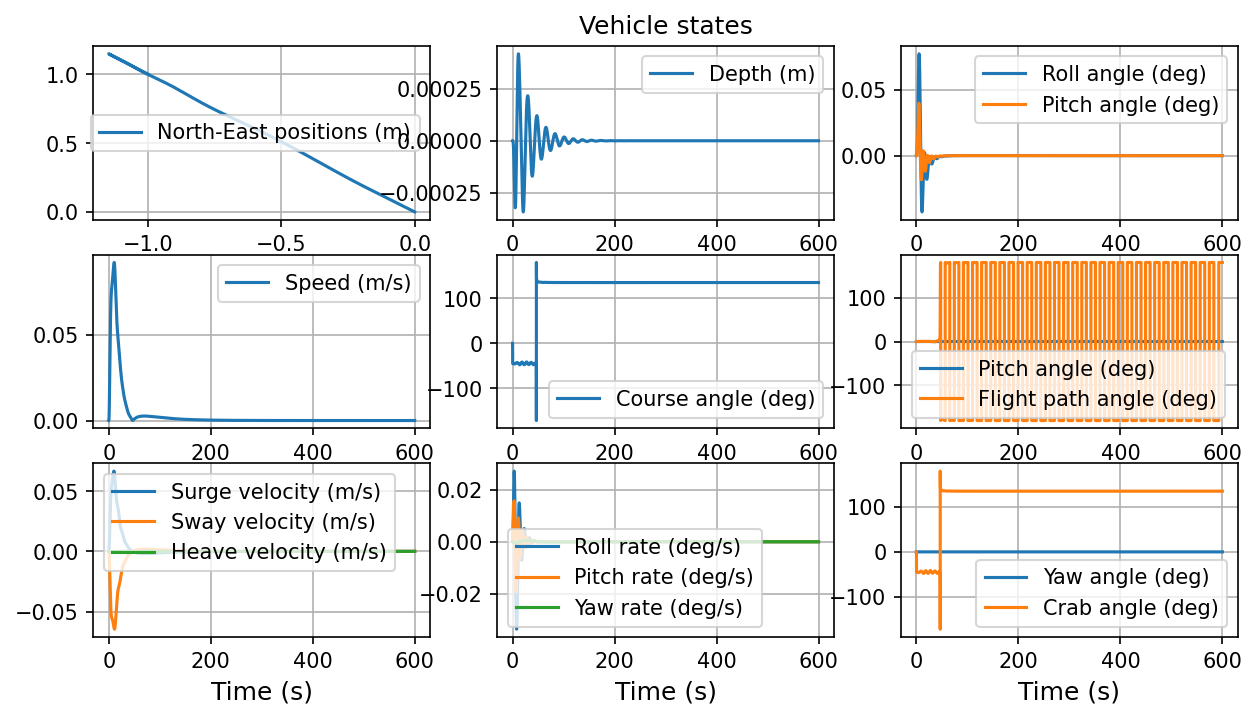

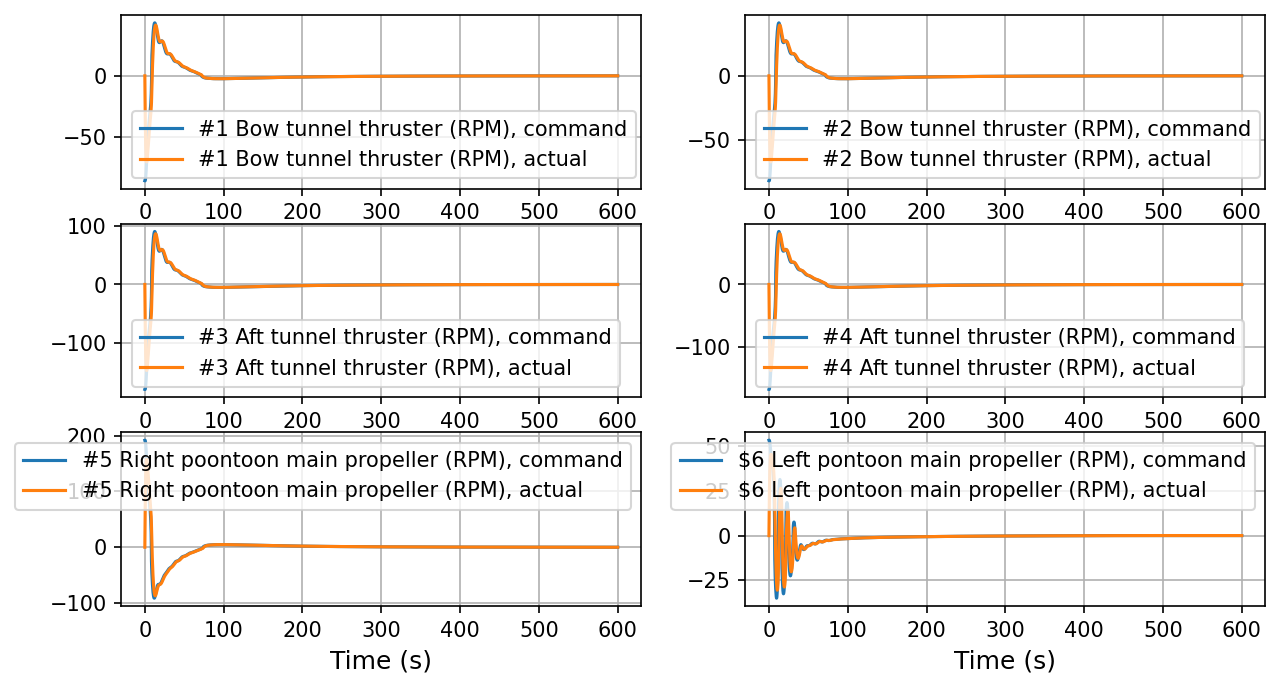

In [104]:
plotVehicleStates(simTime, simData, 1)
plotControls(simTime, simData, vehicle, 2)

In [105]:
numDataPoints = 5                 # number of 3D data points
FPS = 10                            # frames per second (animated GIF)
filename = '3D_animation.gif'       # data file for animated GIF
browser = 'safari'

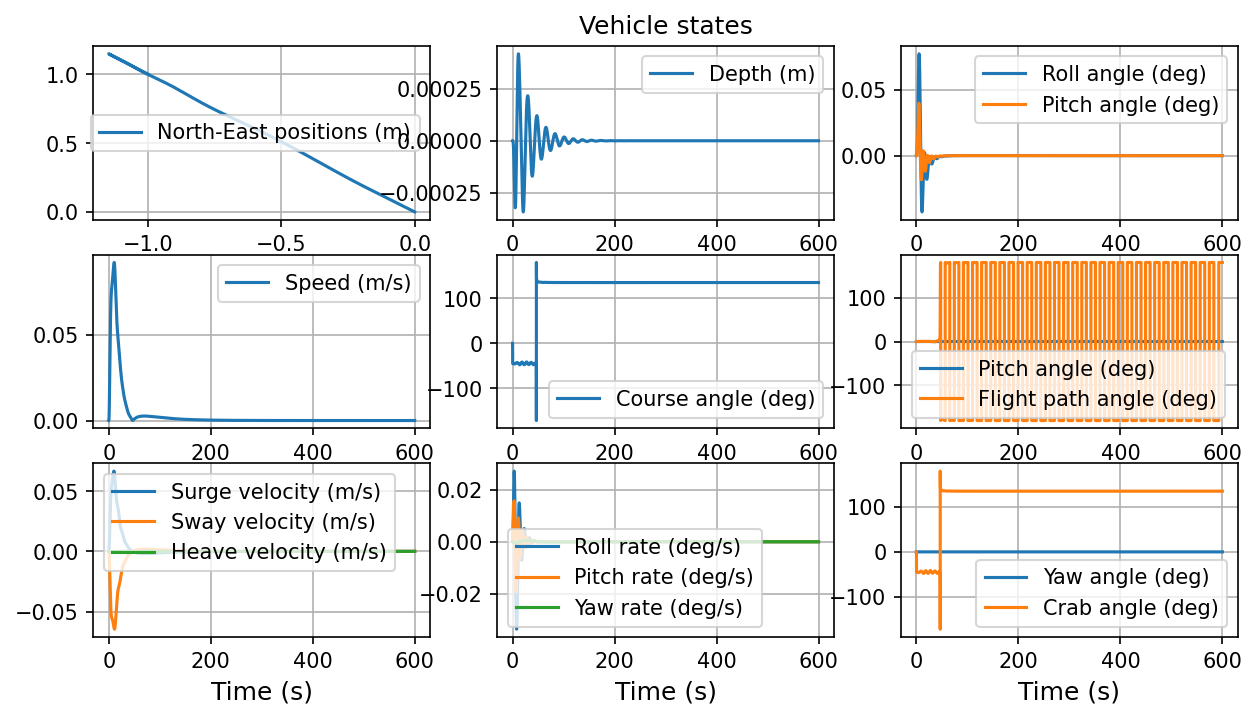

In [106]:
plotVehicleStates(simTime, simData, 3)

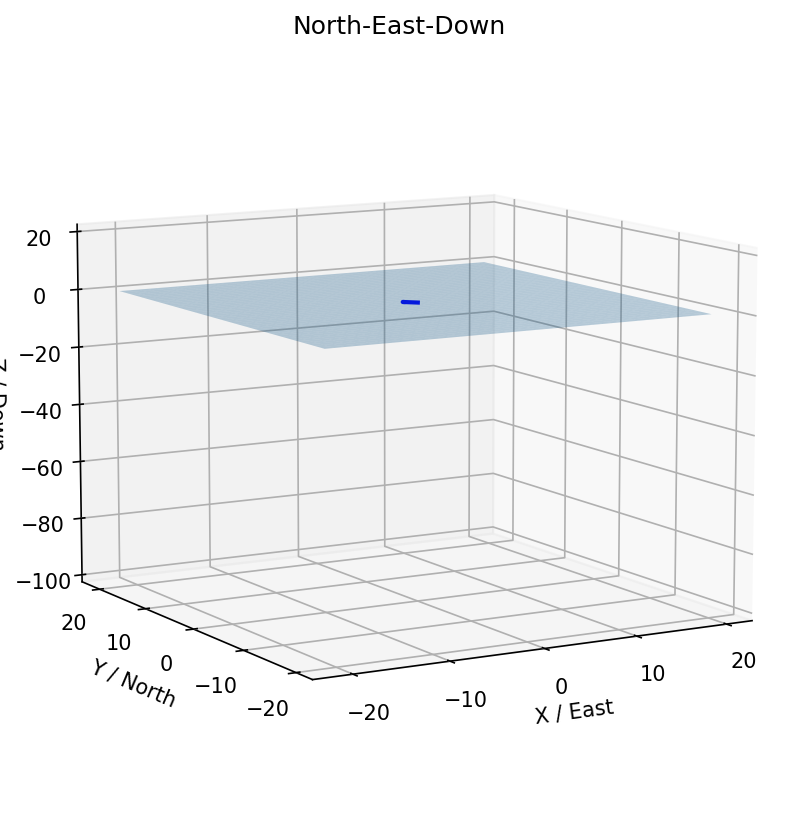

In [107]:
plot3D(simData, numDataPoints, FPS, filename, 3)

In [108]:
def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx

In [109]:
class MyTime:
    def __init__(self):
        self.my_t = 0
        self.v_m = np.array([0,0,0,0,0,0]).astype(np.float64)
        self.progression = [i for i in range(650)]
        self.wall_clock = datetime.now()
        self.x_ve = 0
        self.y_ve = 0
        self.z_ve = 0
        self.phi_ve = 0
        self.theta_ve = 0
        self.psi_ve = 0
        self.top_tension = 0
        self.sagbend_strain = 0
        self.my_iter = 0

### Dynamics

In [110]:
def dynamic_func(t, Q, coefs, T, calibr):
    
    x,y,z=Q[0:N],Q[2*N:3*N],Q[4*N:5*N]
    dx,dy,dz=Q[1*N:2*N],Q[3*N:4*N],Q[5*N:6*N]
    φ,θ,ψ=Q[6*N:7*N],Q[8*N:9*N],Q[10*N:11*N]
    dφ,dθ,dψ=Q[7*N:8*N],Q[9*N:10*N],Q[11*N:12*N]
    
    idx = find_nearest(np.array(ans_t),  t)
    
    del_t = idx-T.my_t
    if del_t<0:
        idx=T.my_t
        
    x_ve = simData[:, 0][idx]
    y_ve = simData[:, 1][idx]
    z_ve = simData[:, 2][idx]
    phi_ve = ssa(simData[:, 3][idx])
    theta_ve = ssa(simData[:, 4][idx])
    psi_ve = ssa(simData[:, 5][idx])
    
    RET = Ret(φ,θ,ψ)

    vessel_movement = np.zeros(6)
    
    
    vessel_movement[0] = (x_ve - T.x_ve)
    vessel_movement[1] = (y_ve - T.y_ve)
    vessel_movement[2] = (z_ve - T.z_ve)
    vessel_movement[3] = (phi_ve - T.phi_ve)
    vessel_movement[4] = (theta_ve - T.theta_ve)
    vessel_movement[5] = (psi_ve - T.psi_ve)
    

    vessel_movement/=calibr
    
    dx[-1],dy[-1],dz[-1],dφ[-1],dθ[-1],dψ[-1]=(vessel_movement[0],
                                              vessel_movement[1],
                                              vessel_movement[2],
                                              vessel_movement[3],
                                              vessel_movement[4],
                                              vessel_movement[5])
    

    fors, mom, angle = PipeForce(x, y, z, list(vessel_movement), coefs)
    
    Z0 = fors.squeeze()
    Z1 = d_s(ne, x, y, z, φ, θ, ψ).T
    Z2 = ne_hat(x, y, z, dx, dy, dz).T

    Z = (Z1 + Z2 - Z0)


############################################################
    ddx,ddy, ddz = (Z/mp).T
############################################################
    
    C0 = np.einsum('ijk,ik->ij', Π(φ,θ,ψ), angle).squeeze()    
    C1 = d_s(me, φ, θ, ψ, φ, θ, ψ)
    C = (C1.T - C0)

    A0 = Jrho(RET,Jrho0)
    A_fin = np.einsum('ijk,ikr->ijr', A0, Π(φ,θ,ψ))
    

    B = np.einsum('ijk,ik->ij', dΠ(φ, θ, ψ, dφ, dθ, dψ), np.stack((dφ,dθ,dψ), axis=1))
    
    D = w_e(φ,θ,ψ,dφ,dθ,dψ)
    
    G = np.cross(d_s(phi,x,y,z,φ, θ, ψ).T, ne(x, y, z, φ, θ, ψ))
    
    L = np.einsum('ijk,ik->ij',RET, (DR@D.T).T) 

    H = np.cross(D, np.einsum('ijk,ik->ij', A0, D))
    

#############################################
    ddφ,ddθ,ddψ = np.linalg.solve(A_fin, (C + G - L - H - np.einsum('ijk,ik->ij', A0, B))).T
#############################################

    T.my_t=idx
    T.x_ve=x_ve
    T.y_ve=y_ve
    T.z_ve=z_ve
    T.phi_ve = phi_ve
    T.theta_ve = theta_ve
    T.psi_ve = psi_ve

    if t>T.progression[0]:
        T.progression.pop(0)
        print('Physical time: ', t, ' Iteration wall-clock time: ', datetime.now() - T.wall_clock )
        T.wall_clock = datetime.now()   
         
    
    ans=np.concatenate([dx, ddx, 
                        dy, ddy, 
                        dz, ddz, 
                        dφ, ddφ, 
                        dθ, ddθ, 
                        dψ, ddψ
                       ], axis=0)
   
   
    if t>1:
        ax=np.einsum('ijk,ik->ij',np.linalg.inv(RET),ne(x, y, z, φ, θ, ψ))
        
        T.top_tension=max(T.top_tension, np.max(ax[-1,:]))
    
        ben=np.max(np.einsum('ijk,ik->ij',np.linalg.inv(RET), 
                         me(φ, θ, ψ, φ, θ, ψ)))/(mp*9.81*np.sqrt((x[-1]-x0_[-1])**2+
                                                                 (y[-1]-0)**2+(z[-1]-z0_[-1])**2)**2)

        I=3.14*(d0**4-dI**4)/64
        strain=np.max(ben)*d0/(2*E*I)    
        
        T.sagnend_strain=max(T.sagbend_strain, strain)
    T.my_iter+=1
    
    return ans

In [111]:
T_ = MyTime()

# initial conditions - to control dynamics
q0[6*N:7*N], q0[8*N:9*N], q0[10*N:11*N] = (np.array([0.01 for i in range(N)]),
                                          np.array([0.000001 for i in range(N)]),
                                          np.array([0.001257*i/N for i in range(N)]))

# BC0123=np.array([0 for i in range(N)])
# BC0123[-1]=0.01

# q0[6*N:7*N], q0[8*N:9*N], q0[10*N:11*N] = (np.array([0 for i in range(N)]),
#                                            BC0123,
#                                            np.array([0 for i in range(N)]))

In [112]:
startTime1 = datetime.now()
us_ = solve_ivp(dynamic_func,
             tspan,
             q0,
             args=(coefs, T_, vessel_motion_calibration_coefficient,))
print(datetime.now() - startTime1)

Physical time:  9.84646067382047e-08  Iteration wall-clock time:  0:00:00.720821
Physical time:  1.0052114239593284  Iteration wall-clock time:  0:02:21.035176
Physical time:  2.0153999884679594  Iteration wall-clock time:  0:03:05.933896
Physical time:  3.003858869133031  Iteration wall-clock time:  0:03:00.101164
Physical time:  4.000508532984061  Iteration wall-clock time:  0:03:15.362084
0:15:28.588931


In [113]:
# max axial tension
T_.top_tension

2357856.445459417

In [114]:
# max bending strain
T_.sagnend_strain*(mp*9.81*np.sqrt((x[-1]-x0_[-1])**2+(y[-1]-0)**2+(z[-1]-z0_[-1])**2)**2)

0.00012622759400349984

### Results

In [115]:
fin=us_

In [116]:
fin

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  9.846e-06 ...  4.995e+00  5.000e+00]
        y: [[ 0.000e+00  3.337e-25 ...  1.910e-05  1.914e-05]
            [ 1.103e+01  1.103e+01 ...  1.092e+01  1.092e+01]
            ...
            [ 0.000e+00 -5.352e-20 ...  7.515e-14  7.510e-14]
            [ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]]
      sol: None
 t_events: None
 y_events: None
     nfev: 2564
     njev: 0
      nlu: 0

In [117]:
t=fin.t

In [118]:
fin=fin.y.T

In [119]:
t.shape, fin.shape

((285,), (285, 240))

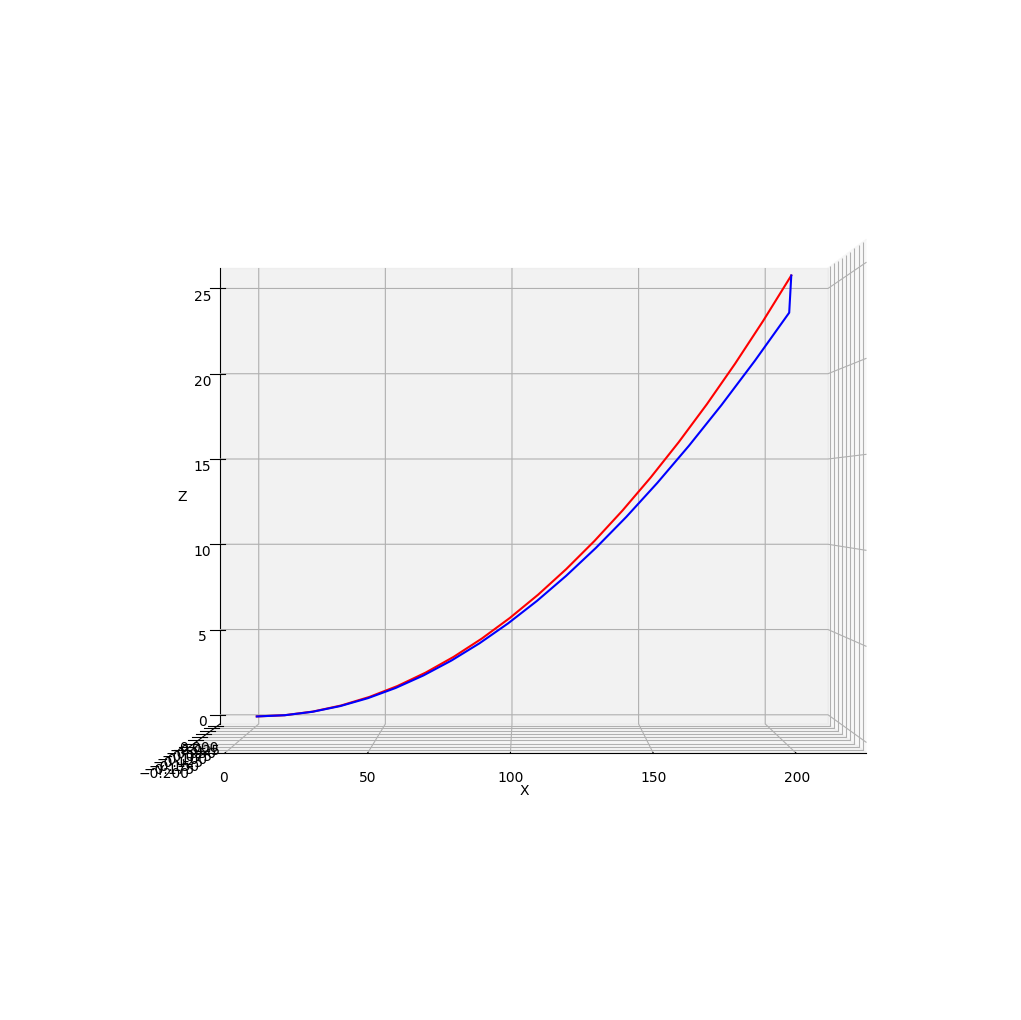

In [120]:
fig=plt.figure(figsize=(13,13))
ax = fig.add_subplot(projection = '3d')

X0=fin[0,[i for i in range(0,N)]]
Y0=fin[0,[i for i in range(2*N,3*N)]]
Z0=fin[0,[i for i in range(4*N,5*N)]]

j=-1
X=fin[j,[i for i in range(0,N)]]
Y=fin[j,[i for i in range(2*N,3*N)]]
Z=fin[j,[i for i in range(4*N,5*N)]]

num_true_pts = 200
tck, u = interpolate.splprep([X,Y,Z], s=2)
u_fine = np.linspace(0,1,num_true_pts)
x_fine, y_fine, z_fine = interpolate.splev(u_fine, tck)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.plot(X0,Y0,Z0, color='r')
ax.plot(X,Y,Z, color='b')
ax.view_init(0,-90)
plt.show()

In [121]:
X,Y,Z

(array([1.91384245e-05, 1.09161200e+01, 2.18470194e+01, 3.27891974e+01,
        4.37409627e+01, 5.47018131e+01, 6.56720987e+01, 7.66528755e+01,
        8.76457501e+01, 9.86529045e+01, 1.09676875e+02, 1.20720338e+02,
        1.31785339e+02, 1.42872389e+02, 1.53979089e+02, 1.65098187e+02,
        1.76220798e+02, 1.87341160e+02, 1.98456636e+02, 2.09515416e+02]),
 array([ 1.91376711e-09,  3.65580490e-04, -5.18582240e-04, -2.74190568e-03,
        -6.35185341e-03, -1.13567797e-02, -1.77544987e-02, -2.55429438e-02,
        -3.47221126e-02, -4.52943291e-02, -5.72635904e-02, -7.06344370e-02,
        -8.54121938e-02, -1.01601389e-01, -1.19203708e-01, -1.38216959e-01,
        -1.58636020e-01, -1.80457341e-01, -2.03681059e-01, -3.09052831e-09]),
 array([-2.45271692e-03,  6.62523199e-02,  2.72477130e-01,  6.16299608e-01,
         1.09785712e+00,  1.71732778e+00,  2.47491125e+00,  3.37084090e+00,
         4.40539954e+00,  5.57893985e+00,  6.89189001e+00,  8.34475305e+00,
         9.93805067e+00,  1.

In [122]:
X0,Y0,Z0

(array([  0.        ,  11.02712714,  22.05425428,  33.08138141,
         44.10850855,  55.13563569,  66.16276283,  77.18988997,
         88.21701711,  99.24414424, 110.27127138, 121.29839852,
        132.32552566, 143.3526528 , 154.37977994, 165.40690707,
        176.43403421, 187.46116135, 198.48828849, 209.51541563]),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0.]),
 array([ 0.        ,  0.07074654,  0.28299779,  0.63678871,  1.13217754,
         1.76924585,  2.54809852,  3.46886379,  4.53169324,  5.73676187,
         7.08426809,  8.57443374, 10.20750417, 11.98374825, 13.90345843,
        15.96695076, 18.17456499, 20.52666459, 23.02363679, 25.66589272]))

In [123]:
us=fin.T

In [124]:
us.shape

(240, 285)

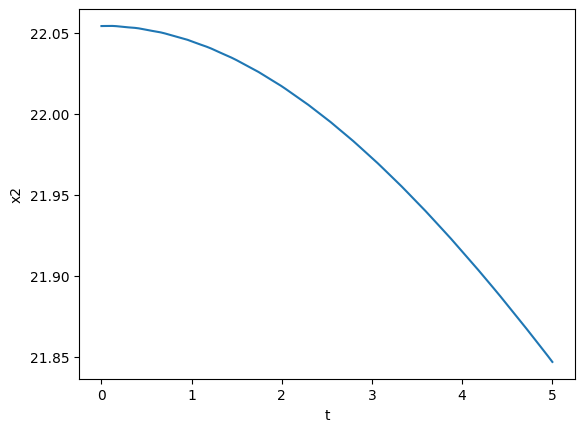

In [125]:
plt.plot(t,us.T[:,2],'-')
plt.xlabel('t')
plt.ylabel('x2')
plt.show()

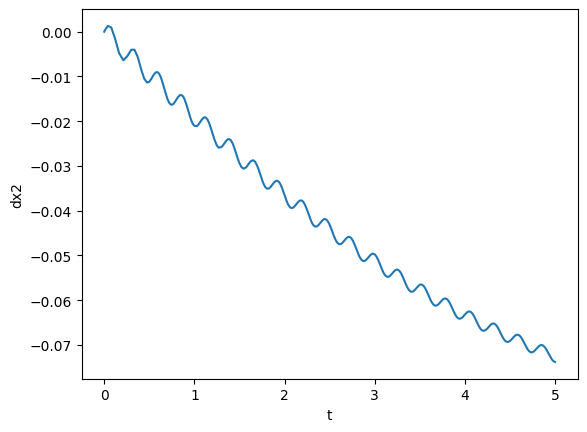

In [126]:
plt.plot(t,us.T[:,N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dx2')
plt.show()

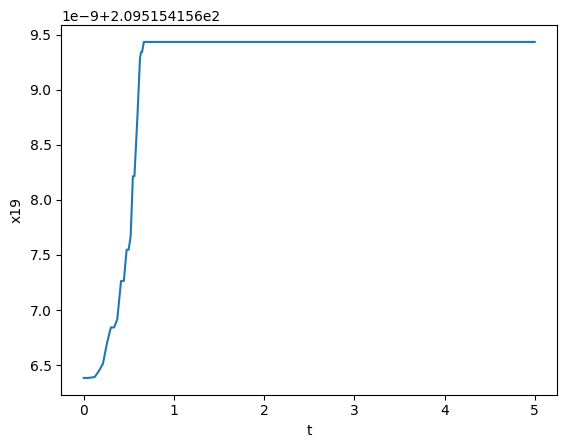

In [127]:
plt.plot(t,us.T[:,N-1] ,'-')
plt.xlabel('t')
plt.ylabel('x{}'.format(N-1))
plt.show()

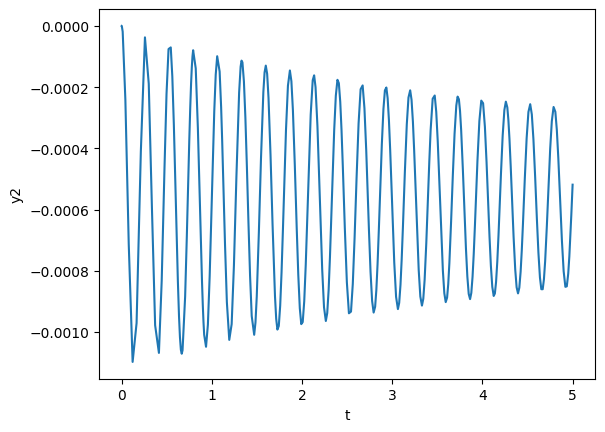

In [128]:
plt.plot(t,us.T[:,2*N +2] ,'-')
plt.xlabel('t')
plt.ylabel('y2')
plt.show()

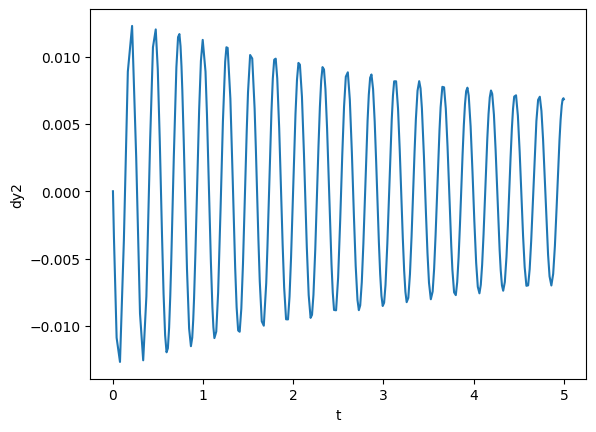

In [129]:
plt.plot(t,us.T[:,3*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dy2')
plt.show()

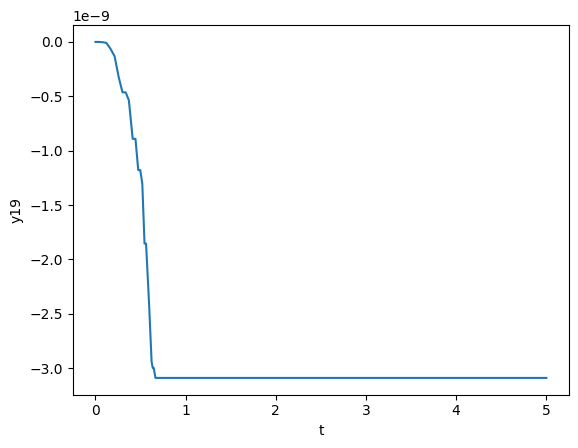

In [130]:
plt.plot(t,us.T[:,2*N+(N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('y{}'.format(N-1))
plt.show()

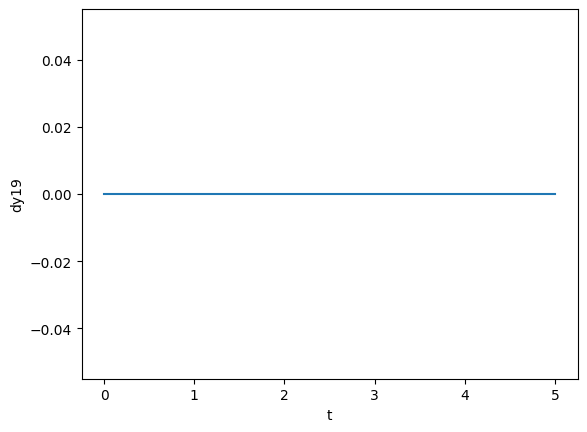

In [131]:
plt.plot(t,us.T[:,3*N+(N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('dy{}'.format(N-1))
plt.show()

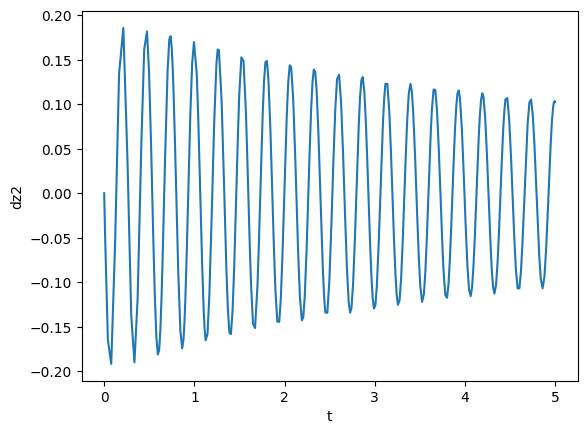

In [132]:
plt.plot(t,us.T[:,5*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dz2')
plt.show()

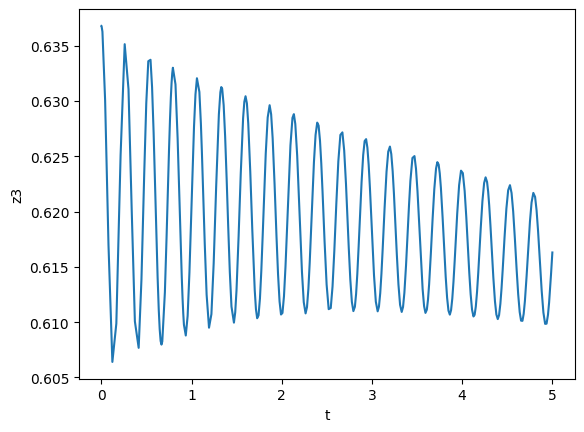

In [133]:
plt.plot(t,us.T[:,4*N+3] ,'-')
plt.xlabel('t')
plt.ylabel('z3')
plt.show()

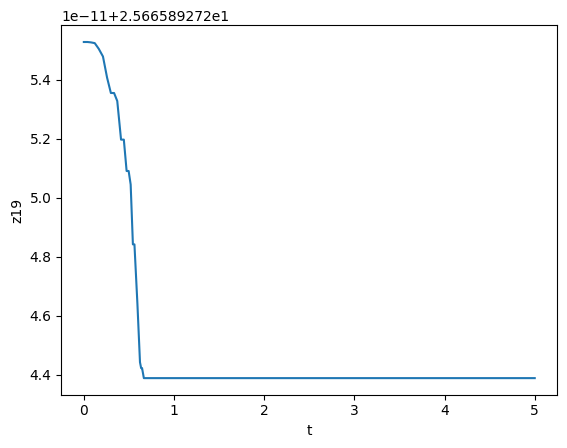

In [134]:
plt.plot(t,us.T[:,4*N + (N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('z{}'.format(N-1))
plt.show()

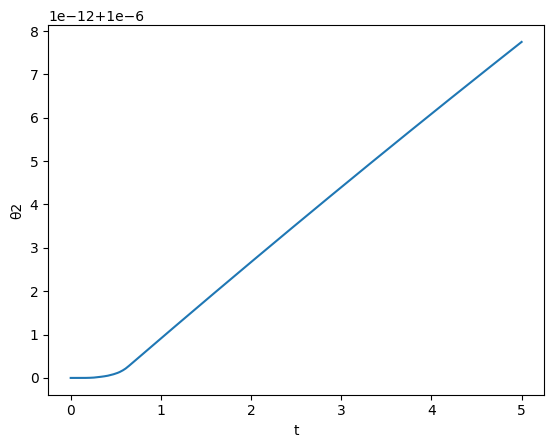

In [135]:
plt.plot(t,us.T[:,8*N+2],'-')
plt.xlabel('t')
plt.ylabel('θ2')
plt.show()

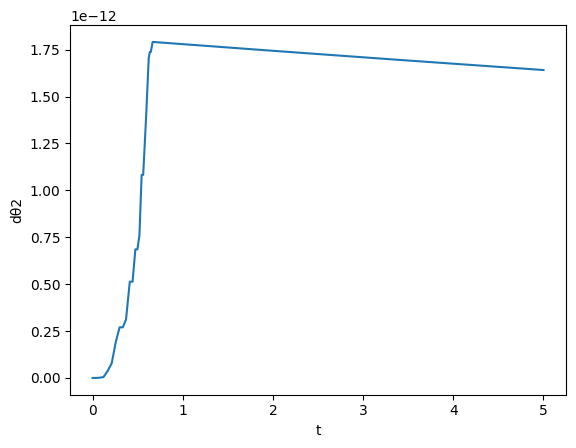

In [136]:
plt.plot(t,us.T[:,9*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dθ2')
plt.show()

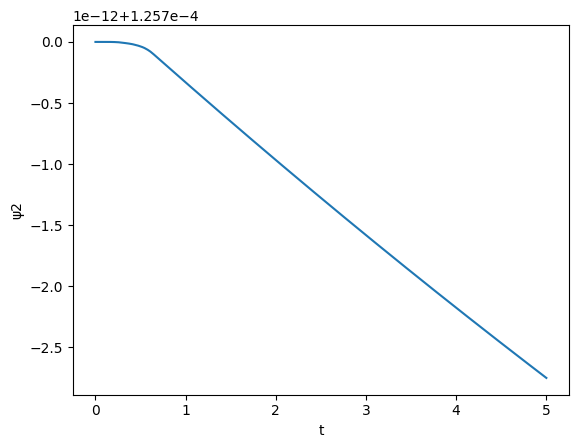

In [137]:
plt.plot(t,us.T[:,10*N+2],'-')
plt.xlabel('t')
plt.ylabel('ψ2')
plt.show()

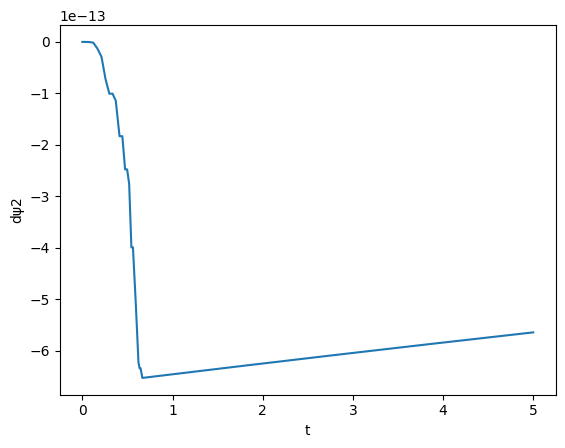

In [138]:
plt.plot(t,us.T[:,11*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dψ2')
plt.show()

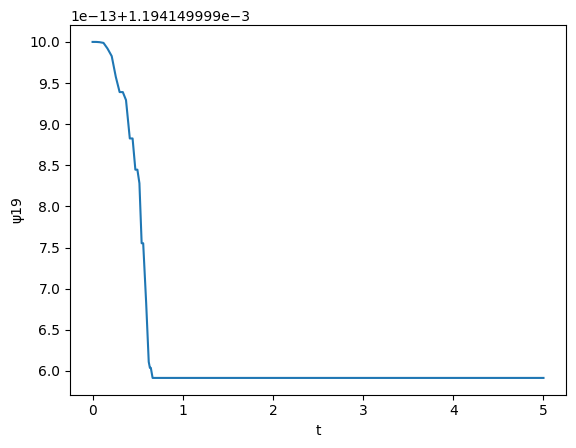

In [139]:
plt.plot(t,us.T[:,10*N + (N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('ψ{}'.format(N-1))
plt.show()

In [140]:
X010=us.T[:,0*N:1*N]

In [141]:
Y010=us.T[:,2*N:3*N]

In [142]:
Z010=us.T[:,4*N:5*N]

In [143]:
# simulation = np.stack([X010,Y010,Z010],axis=2) 

# FPS = 30                      
# frame_duration = 1000 / FPS

# frames = []
# for t in range(simulation.shape[0]):
#     x = simulation[t,:,0]
#     y = simulation[t,:,1]
#     z = simulation[t,:,2]

#     frames.append(go.Frame(
#         data=[
#             go.Scatter3d(
#                 x=x, y=y, z=z,
#                 mode="lines+markers",
#                 marker=dict(size=5, color=list(range(12)), colorscale="Viridis"),
#                 line=dict(width=4)
#             )
#         ],
#         name=f"t={t}"
#     ))

# # First frame
# x0, y0, z0 = simulation[0,:,0], simulation[0,:,1], simulation[0,:,2]

# fig = go.Figure(
#     data=[go.Scatter3d(x=x0, y=y0, z=z0, mode="lines+markers")],
#     frames=frames
# )

# # Animation controls
# fig.update_layout(
#     title="Pipeline Simulation ",
#     scene=dict(
#         xaxis_title="X",
#         yaxis_title="Y",
#         zaxis_title="Z",
#         xaxis=dict(range=[0, 300]),
#         yaxis=dict(range=[-50, 50]),
#         zaxis=dict(range=[0, 40]),
#         aspectmode="data",
       
#     ),
#     updatemenus=[{
#         "type": "buttons",
#         "buttons": [
#             {
#                 "label": "Play",
#                 "method": "animate",
#                 "args": [None, {"frame": {"duration": frame_duration, "redraw": True}}]
#             },
#             {
#                 "label": "Pause",
#                 "method": "animate",
#                 "args": [[None], {"frame": {"duration": 0}}]
#             }
#         ]
#     }]
# )

# fig.show()